# Credit Card Fraud Detection With Limited Feature Transparency:

## Introduction and Outline: 
The goal of this project is to create a model that can accurately distinguish fraudulent and non-fraudulent credit card transaction using PCA-transformed dataset, with a focus on maximising precision and recall.

Before going in depth with the project outline firstly need to discuss the data and some of its known limitations:
1) The data is extremely imbalanced in a dataset of 283253 card transaction only 473  are fraudulent.
2) Features have been PCA transformed to be anonymised and can't rely on domain intuition for individual features. 
3) Time in this data is not in a timestamp format it is a linear progression where each transaction is measured in seconds after the first transaction (first transaction = 0, third transaction = 1, etc.) so you cannot determine seasonality based insights.

Given these restraints the stengths will lie in:
- Time based patterns 
- The behaviour of amounts which are real and interpretable 
- Strong evaluation logic

**Outline:**
1) Given the limitations of the data Exploratory Data Analysis will focus on:
    - Dataset Overview: Understand scale and imbalance, determine class distribution, missing/duplicate values and basic integrity.
    - Amount Analysis: Distribution of transaction amount, size and dispersion of fraudulent transactions. 
    - Time Based Analysis: Transactions vs. time, fraud occurrence over time and fraud rate over time.
    - PCA Feature Analysis: Can't interpret individually but can explore patterns, correlation of fraud and feature values and their relationships and fraud vs non-fraud distribution comparisons.

2) Model Training and Testing:
    - Split data into training, validation and test sets using a stratified split to address class imbalance.
    - Create an evaluation procedure to determine best threshold for model performance, F1 score (our main metric), Precision, Recall, APS and ROC-AUC as a supporting metric to get a hollistic view of model performance and how it translates to fraud detection. 
    - Draw final conclusions and test on the held out test data.

## Exploratory Data Analysis:

In [49]:
#importing necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
from lightgbm import LGBMClassifier
from matplotlib import pyplot as plt
from scipy.stats import spearmanr
from sklearn import metrics
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
#storing in a dataframe
transactions_df = pd.read_csv('/Users/micha/Credit Fraud/creditcard.csv')

In [3]:
#general overview of data
transactions_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
#general info for data
transactions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [5]:
#confirming class imbalance
transactions_df['Class'].value_counts().reset_index()

,Class,count
0,0,284315
1,1,492


In [6]:
#numerical feature statistical descriptions
transactions_df[['Time', 'Amount']].describe()

,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


### General Overview Conclusions: 
- The data types and overall structure of the data is reasonable and shouldn't need to much editing.
- Confirmed there is extreme class imbalance between fraudulent and non-fraudulent transactions.
- Statistical description of amount shows us there are some serious outliers with the highest credit transaction being over $25000 and the average transaction being $88. 
- All of these transactions occured in 172792 seconds of the first transaction which is almost 48 hours (2 days).

## Amount Analysis: 

In [7]:
#transaction amounts
transaction_amount = transactions_df[['Amount', 'Class']].reset_index(drop=True)

#amount for fraud/non-fraud
fraud_amount = transaction_amount[transaction_amount['Class'] == 1]
non_fraud_amount = transaction_amount[transaction_amount['Class'] == 0]

#droppin unecessary 'Class' column
fraud_amount.drop(columns=['Class'], inplace=True)
non_fraud_amount.drop(columns=['Class'], inplace=True)

#creating log transformed data (while taking into account 0 amounts) for amounts
fraud_log_amounts = np.log1p(fraud_amount['Amount'])
non_fraud_log_amounts = np.log1p(non_fraud_amount['Amount'])

#getting general description of both log transformed classes
print(fraud_log_amounts.describe())
print(f'\n{non_fraud_log_amounts.describe()}')

count    492.000000
mean       2.820596
std        2.214342
min        0.000000
25%        0.693147
50%        2.327270
75%        4.671800
max        7.662407
Name: Amount, dtype: float64

count    284315.000000
mean          3.152762
std           1.655468
min           0.000000
25%           1.894617
50%           3.135494
75%           4.357350
max          10.153941
Name: Amount, dtype: float64


Text(0.5, 1.0, 'Fraud vs. Non-Fraud Log Transformed Amounts:')

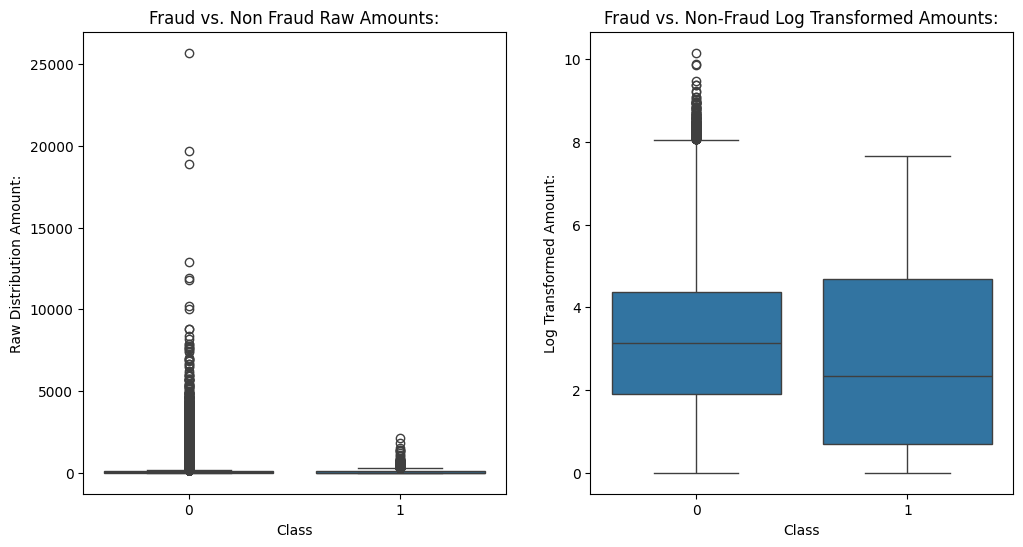

In [8]:
#creating a box plot showing raw amount distributions and log transformed distributions

transaction_amount['log_amount'] = np.log1p(transaction_amount['Amount'])
fig, axs = plt.subplots(1, 2, figsize=(12,6))

sns.boxplot(x=transaction_amount['Class'], y=transaction_amount['Amount'], ax=axs[0])
axs[0].set_ylabel('Raw Distribution Amount:')
axs[0].set_title('Fraud vs. Non Fraud Raw Amounts:')
sns.boxplot(x=transaction_amount['Class'], y=transaction_amount['log_amount'], ax=axs[1])
axs[1].set_ylabel('Log Transformed Amount:')
axs[1].set_title('Fraud vs. Non-Fraud Log Transformed Amounts:')

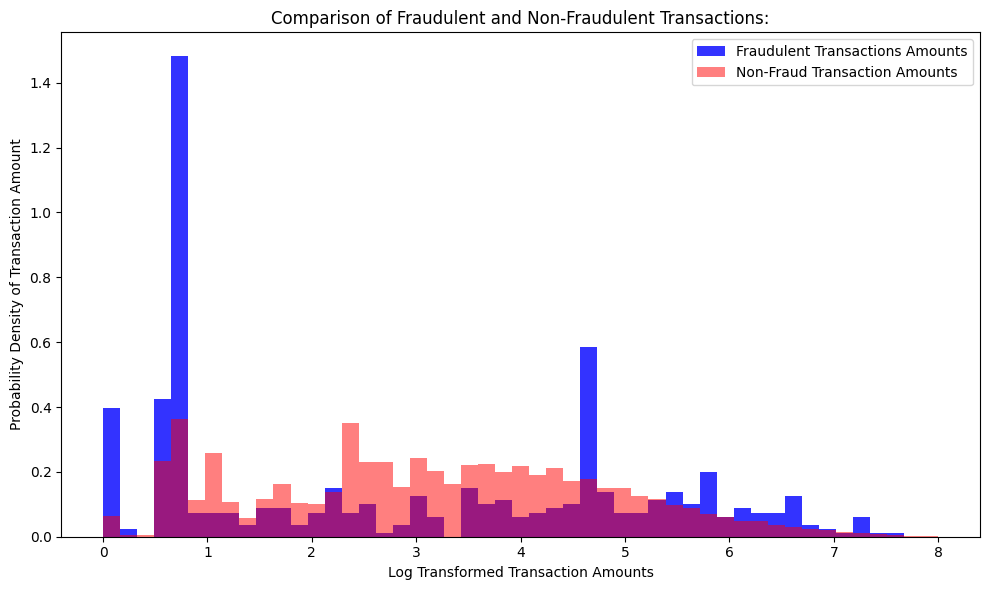

In [9]:
#histogram showing log transformed fraud vs non-fraud transaction

plt.figure(figsize=(10,6))

bins = np.linspace(0, 8)
plt.hist(fraud_log_amounts, bins=bins, density=True, alpha=0.8, label='Fraudulent Transactions Amounts', color='blue')
plt.hist(non_fraud_log_amounts,bins=bins, density=True, alpha=0.5, label='Non-Fraud Transaction Amounts', color='red')
plt.title('Comparison of Fraudulent and Non-Fraudulent Transactions:')
plt.xlabel('Log Transformed Transaction Amounts')
plt.ylabel('Probability Density of Transaction Amount')
plt.legend()
plt.tight_layout()

### Amount Analysis Conclusions: 
1) Boxplot Conclusions (Raw vs. log transformed data): 
    - It's clear from the boxplots that fraud occupies a much smaller range of amounts compared to non-fraud transaction, this is likely due to the extreme class imbalance, but also that fraudsters typically keep their transactions lower to avoid detection.
    - Can see from the log-transformed box plot though the range of fraudulent transaction lies between small and mid-sized transactions whereas non-fraud transactions have a much wider range but are spread more commonly around mid-sized transactions and contain all of the outliers in the dataset. This makes sense because credit card transactions typically aren't larger than a few thousand dollars. 

2) Histogram Conclusions (log transformed data): 
    - From the overlayed histogram we can see a few things immediately, fraud occurs much more frequently at lower values, non-fraud is spread around the mid-range. 
    - Fraudulent transaction tend to spike at certain transaction amounts rather than keeping a relatively consistent trend across all transaction amounts, this could be because of different fraud strategies (like making many small credit transactions/applications over a short period of time) or using synthtic identity fraud to create a 'clean' credit profile then making large transactions before disapearing. 

## Class Imbalance Analsis: 

In [10]:
#checking class imbalance
transactions_df['Class'].value_counts().reset_index()

,Class,count
0,0,284315
1,1,492


In [11]:
#checking proportion of fraudulent transactions
class_prop = transactions_df['Class'].value_counts(normalize=True).mul(100).round(2)
class_prop.reset_index()

,Class,proportion
0,0,99.83
1,1,0.17


(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

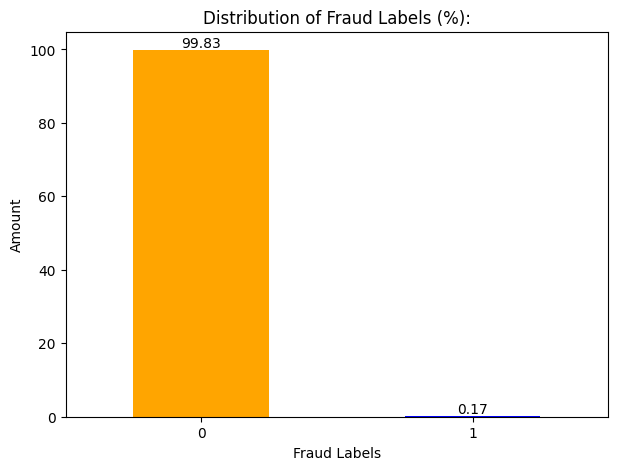

In [12]:
#bar graph of fraud vs. non-fraud credit transactions

plt.figure(figsize=(7, 5))
class_prop.plot(kind='bar', color=['orange', 'blue'])
for i, count in enumerate(class_prop):
    plt.text(i, count, str(count), ha='center', va='bottom')
plt.title('Distribution of Fraud Labels (%):')
plt.xlabel('Fraud Labels')
plt.ylabel('Amount')
plt.xticks(rotation=0)

In [13]:
#checking missing values
transactions_df.isna().sum().sum()

np.int64(0)

In [14]:
#checking duplicate values
transactions_df.duplicated().sum()

np.int64(1081)

In [15]:
#creating seperate duplicate value dataframe to analyse correct approach for handling 
duplicated_transactions = transactions_df[transactions_df.duplicated(keep=False)]
duplicated_transactions.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0


In [16]:
#checking class imbalance for duplicate values
duplicated_transactions['Class'].value_counts().reset_index()

,Class,count
0,0,1822
1,1,32


In [17]:
#checking proportion fraud vs non-fraud for duplicate values
dup_class_prop = duplicated_transactions['Class'].value_counts(normalize=True).mul(100).round(2)
dup_class_prop.reset_index()

,Class,proportion
0,0,98.27
1,1,1.73


(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

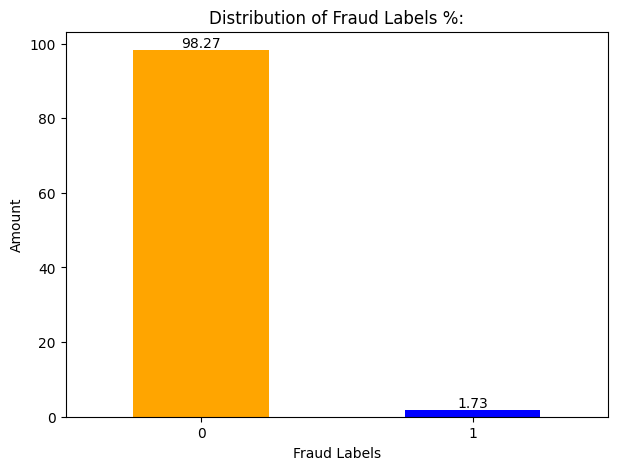

In [18]:
#bar graph showing fraud vs. non-fraud transactions

plt.figure(figsize=(7, 5))
dup_class_prop.plot(kind='bar', color=['orange', 'blue'])
for i, count in enumerate(dup_class_prop):
    plt.text(i, count, str(count), ha='center', va='bottom')
plt.title('Distribution of Fraud Labels %:')
plt.xlabel('Fraud Labels')
plt.ylabel('Amount')
plt.xticks(rotation=0)

In [19]:
#dropping duplicates
transactions_df.drop_duplicates(inplace=True)
transactions_df.duplicated().sum()

np.int64(0)

### Fraud vs. Non-Fraud and Duplicate Value Handling Conclusions:

**Fraud Class Imbalance:**
- Executed a deep dive into the class imbalance fraud vs. non-fraud.
- Fraud makes up only 0.17 percent of all transactions. 
- Serious steps will need to be taken in model training to mitigate class imbalance.

**Duplicate Values:**
- Seperated duplicate values into their own dataframe for analysis in order to determine best approach for handling.
- Checked the class balances for the duplicate values and here fraud represents 1.73 percent of all transactions (about 10x higher)
- Opted to remove these outright from the original dataset because fraudulent transactions are disproportionately duplicated, meaning fraud patterns are overrepresented and can inflate fraud statistics and potentially model performance and runs the risk of a model 'memorising' repeated fraud cases. 

## Time Based Analysis: 

In [20]:
#creating time based bins for analysis (3600 sec intervals = hour based intervals)
start = transactions_df['Time'].min()
step = 3600
end = transactions_df['Time'].max() + step 

bins = np.arange(start, end, step)
transactions_df['hours'] = pd.cut(transactions_df['Time'], bins=bins)

#creating a time df with relevant columns 
transaction_times = transactions_df[['Time', 'hours', 'Class']]

#fraud vs non-fraud times
fraud_times = transaction_times[transaction_times['Class'] == 1]
non_fraud_times = transaction_times[transaction_times['Class'] == 0]

#creating a table for line graph creation with fraud/non-fraud times
fraud_non_fraud = pd.concat([fraud_times, non_fraud_times], axis=0)
lin_table = fraud_non_fraud.groupby(['hours', 'Class'])['Time'].count().reset_index(name='Count')

#getting the total counts of each transaction per interval
total_per_bucket = lin_table.groupby('hours')['Count'].sum().reset_index()
total_per_bucket.rename(columns={'Count': 'total_count'}, inplace=True)

#creating the final table for analysis/visualisations
lin_table = lin_table.merge(total_per_bucket, on='hours', how='left')
lin_table['fraud_proportions'] = (lin_table['Count'] / lin_table['total_count'])
lin_table['hours_mid'] = lin_table['hours'].apply(lambda x: x.mid)

#seperating into fraud and non-fraud and creating rolling average column to smooth data get better picture overall
lin_table_fraud = lin_table[lin_table['Class'] == 1]
lin_table_fraud['rolling_mean_prop'] = lin_table_fraud['fraud_proportions'].rolling(window=7).mean()

lin_table_non_fraud = lin_table[lin_table['Class'] == 0]
lin_table_non_fraud['rolling_mean_prop'] = lin_table_non_fraud['fraud_proportions'].rolling(window=7).mean()

Text(0, 0.5, 'Count of Transactions by Time')

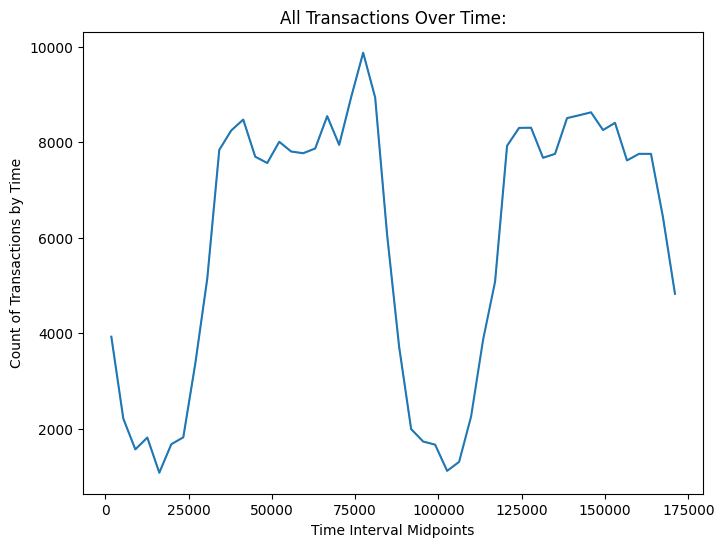

In [21]:
#lineplot of all transactions over time

plt.figure(figsize=(8, 6))
sns.lineplot(lin_table, x='hours_mid', y='total_count')
plt.title('All Transactions Over Time:')
plt.xlabel('Time Interval Midpoints')
plt.ylabel('Count of Transactions by Time')

Text(0, 0.5, 'Proportion of Non-Fraudulent Transactions')

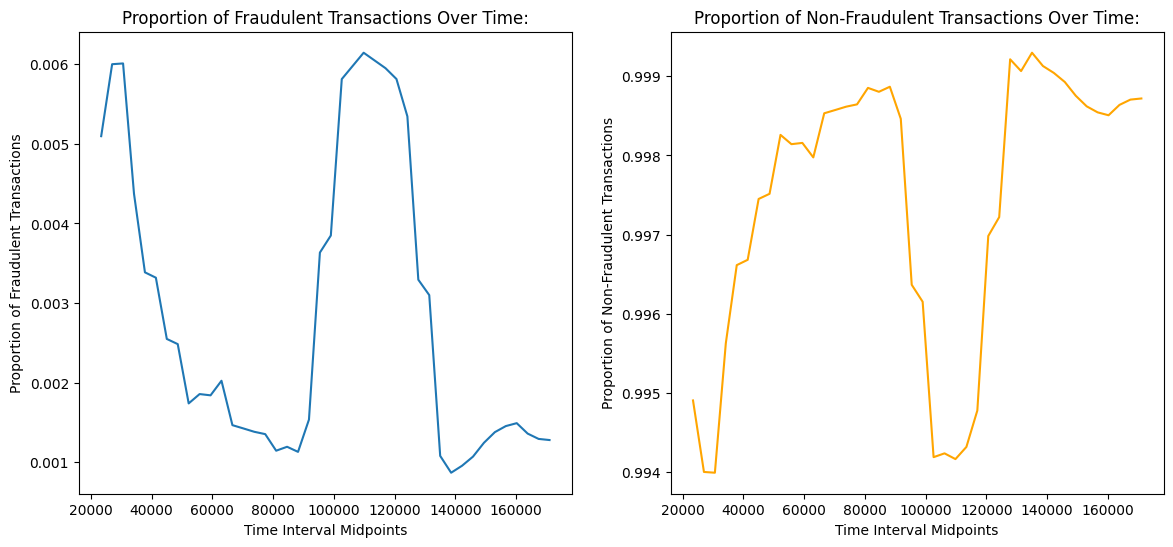

In [22]:
#line plot showing proportion fraudulent vs. non fraudulent transaction over time 
fig, axs = plt.subplots(1, 2, figsize=(14,6))

sns.lineplot(lin_table_fraud, x='hours_mid', y='rolling_mean_prop', ax=axs[0])
axs[0].set_title('Proportion of Fraudulent Transactions Over Time:')
axs[0].set_xlabel('Time Interval Midpoints')
axs[0].set_ylabel('Proportion of Fraudulent Transactions')

sns.lineplot(lin_table_non_fraud, x='hours_mid', y='rolling_mean_prop', ax=axs[1], color='orange')
axs[1].set_title('Proportion of Non-Fraudulent Transactions Over Time:')
axs[1].set_xlabel('Time Interval Midpoints')
axs[1].set_ylabel('Proportion of Non-Fraudulent Transactions')

### Time Based Analysis Conclusions: 
1) Total Transactions Over Time:
    - Here we can see a consistent increase then stabilisation for all transactions over time.
    - There is a steep drop off in all transactions around 100000 second interval midpoint.
    - After this drop off resumes its increase and stabilisation trajectory in a similar fashion to that prior to the drop off. 

2) Fraud vs. Non-Fraud Over Time:
    - These 2 graphs are the mirror image of each other but still paint an interesting picture.
    - There is a steep increase in fraud right where total transactions occur in lower volumes, this tells us that fraud increases during low-activity periods and may be indicative of certain fraud strategies, like taking advantage of less monitoring/alerts, slower human response, etc.


## PCA Feature Analysis: 

In [23]:
#isolating PCA features, class and amount in their own df
v_features = transactions_df.loc[:,'V1': 'Class']
v_features_raw = v_features.copy()
v_features.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,-0.001441,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,1.076407,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,-24.588262,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,-0.535578,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,-0.093237,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,0.453619,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,23.745136,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [24]:
#creating quantile binned intervals for feature values to create a correlation heatmap of fraud proportion for each feature

pca_features = ['V1','V2','V3','V4','V5','V6','V7','V8','V9','V10',
            'V11','V12','V13','V14','V15','V16','V17','V18','V19','V20',
            'V21','V22','V23','V24','V25','V26','V27','V28']

#creating quantile bins 
for feature in pca_features:
    v_features[f'{feature}_quantile_intervals'] = pd.qcut(v_features[feature], 10, duplicates='drop')
 
quantile_binned_dfs = {}
quantile_intervals = ['V1_quantile_intervals', 'V2_quantile_intervals', 'V3_quantile_intervals',
    'V4_quantile_intervals', 'V5_quantile_intervals', 'V6_quantile_intervals', 'V7_quantile_intervals',
    'V8_quantile_intervals', 'V9_quantile_intervals', 'V10_quantile_intervals', 'V11_quantile_intervals',
    'V12_quantile_intervals', 'V13_quantile_intervals', 'V14_quantile_intervals', 'V15_quantile_intervals',
    'V16_quantile_intervals', 'V17_quantile_intervals', 'V18_quantile_intervals', 'V19_quantile_intervals',
    'V20_quantile_intervals', 'V21_quantile_intervals', 'V22_quantile_intervals', 'V23_quantile_intervals',
    'V24_quantile_intervals', 'V25_quantile_intervals','V26_quantile_intervals','V27_quantile_intervals',
    'V28_quantile_intervals'
]
#editing the data for eventual heatmapping 
for interval in quantile_intervals:
    feature = interval.replace('_quantile_intervals', '')
    grouped = v_features.groupby([f'{interval}', 'Class']).size().unstack('Class').reset_index()
    grouped['total_count'] = grouped[0] + grouped[1]
    grouped['fraud_prop'] = (grouped[1] / grouped['total_count']).mul(100).round(2)
    #grouped.drop(columns=[0, 'total_count'], inplace=True)

    quantile_binned_dfs[feature] = grouped

#creating a combined df for fraud proportion for each feature
combined = pd.concat([df[['fraud_prop', 'total_count']] for df in quantile_binned_dfs.values()], axis=1, keys=quantile_binned_dfs.keys())
combined

V1                     V2                     V3              \
Class fraud_prop total_count fraud_prop total_count fraud_prop total_count   
0           0.91       28373       0.08       28373       1.30       28375   
1           0.18       28373       0.03       28373       0.10       28372   
2           0.08       28372       0.03       28372       0.07       28371   
3           0.06       28373       0.02       28373       0.06       28373   
4           0.07       28372       0.04       28372       0.03       28372   
5           0.19       28373       0.02       28373       0.02       28373   
6           0.10       28372       0.06       28372       0.03       28372   
7           0.03       28373       0.06       28373       0.03       28373   
8           0.04       28372       0.13       28372       0.01       28372   
9           0.01       28373       1.19       28373       0.01       28373   

              V4                     V5              ...        V24  \
Class fraud_prop total_count fraud_prop total_count  ... fraud_prop   
0            NaN         NaN       0.84       28373  ...       0.14   
1           0.01     28373.0       0.12       28373  ...       0.26   
2           0.00     28372.0       0.10       28372  ...       0.22   
3           0.02     28373.0       0.06       28373  ...       0.23   
4           0.02     28372.0       0.06       28372  ...       0.11   
5           0.04     28373.0       0.05       28373  ...       0.18   
6           0.03     28372.0       0.07       28372  ...       0.19   
7           0.05     28373.0       0.08       28373  ...       0.16   
8           0.09     28372.0       0.11       28372  ...       0.10   
9           1.42     28373.0       0.17       28373  ...       0.06   

                         V25                    V26                    V27  \
Class total_count fraud_prop total_count fraud_prop total_count fraud_prop   
0           28373       0.25       28373       0.12       28373       0.31   
1           28373       0.12       28373       0.14       28373       0.05   
2           28372       0.10       28372       0.12       28372       0.02   
3           28373       0.14       28373       0.23       28373       0.02   
4           28372       0.14       28372       0.15       28372       0.05   
5           28373       0.18       28373       0.19       28373       0.06   
6           28372       0.12       28372       0.09       28372       0.05   
7           28373       0.17       28373       0.19       28373       0.07   
8           28372       0.16       28372       0.35       28372       0.09   
9           28373       0.29       28373       0.10       28373       0.94   

                         V28              
Class total_count fraud_prop total_count  
0           28373       0.36       28373  
1           28374       0.08       28373  
2           28371       0.04       28372  
3           28373       0.03       28374  
4           28372       0.05       28371  
5           28373       0.02       28373  
6           28372       0.06       28372  
7           28373       0.10       28373  
8           28372       0.17       28372  
9           28373       0.77       28373  

[10 rows x 56 columns]

### Note on Quantile Binned Features:
Can see that binning has worked as intended and each bin has almost identical counts of samples in them meaning we can trust fraud proportions across all bins and don't have to worry about disproportionate counts distorting values across bins and we can safely compare across all bins. 

Text(158.22222222222223, 0.5, 'Quantile Bins for Features')

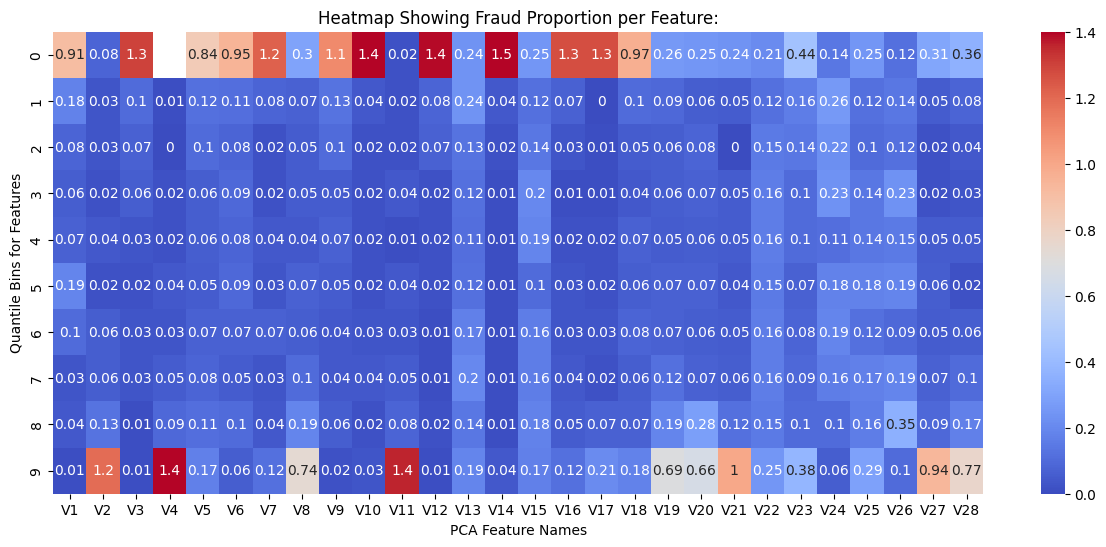

In [25]:
#heatmap showing fraud rate per PCA feature
heatmap = combined.xs('fraud_prop', axis=1, level=1)
plt.figure(figsize=(15, 6))
sns.heatmap(heatmap, annot=True, vmin=0, vmax=1.4, cmap='coolwarm')
plt.title('Heatmap Showing Fraud Proportion per Feature:')
plt.xlabel('PCA Feature Names')
plt.ylabel('Quantile Bins for Features')

In [26]:
#using a custom function to create pca features for line graph creation 
def create_pca_features(df, feature_name):
    
    #creating equal width bins (instead of quantile bins) to check numerically the differences between fraud proportion and density
    start = min(df[feature_name])
    end = max(df[feature_name])
    step = (end - start) / 20
    
    bins = np.arange(start, end, step)
    df[f'{feature_name}_intervals'] = pd.cut(df[feature_name], bins=bins)

    grouped_df = df.groupby([f'{feature_name}_intervals', 'Class']).size().unstack('Class').fillna(0).reset_index(names='intervals')
    grouped_df.rename(columns={ 0: '0', 1: '1'}, inplace=True)

    #adding data according to visualisation need 
    grouped_df['total_count'] = grouped_df['0'] + grouped_df['1']
    grouped_df['fraud_prop'] = (grouped_df['1'] / grouped_df['total_count']).mul(100)
   
    pca_feature_threshold = len(df) * 0.001 
    mask = grouped_df['total_count'] < pca_feature_threshold
    grouped_df.loc[mask, 'fraud_prop'] = np.nan 

    grouped_df['rolling_mean_prop'] = grouped_df['fraud_prop'].rolling(3, min_periods=1).mean()

    grouped_df['interval_mid'] = grouped_df['intervals'].apply(lambda x: x.mid)
    grouped_df['interval_mid'] = pd.to_numeric(grouped_df['interval_mid']).round(3)
    
    bin_width = (grouped_df['intervals'].cat.categories.right) - (grouped_df['intervals'].cat.categories.left)
    grouped_df['bin_width'] = bin_width[grouped_df['intervals'].cat.codes]
    grouped_df['fraud_density'] = (grouped_df['1'] / grouped_df['bin_width']).round(2)
    
    #creating a singular df with all results at the end 
    grouped_df= pd.melt(grouped_df, id_vars=['intervals', 'total_count', 'fraud_prop', 'interval_mid', 'rolling_mean_prop', 'bin_width', 'fraud_density'], value_vars=['0', '1'], var_name='class', value_name='count')
   
    return grouped_df

### Note on PCA Feature Creation:
This function constructs equal-width binned representations of each PCA feature to better understand how fraud behaviour varies across the numerical range of the feature. Unlike quantile binning (used earlier for stable comparisons), equal-width bins preserve the true value scale, allowing us to interpret where in the feature space fraud is concentrated:

- For each feature, the data is divided into 20 evenly spaced intervals between the minimum and maximum values. 
- Within each bin, we compute key metrics including total transaction count, fraud count, and fraud proportion (as a percentage). Because equal-width bins can produce very small sample sizes—especially in the tails—we apply a minimum count threshold (0.1% of the dataset). 
- Bins that do not meet this threshold are considered unreliable, and their fraud proportions are masked to prevent noisy or misleading spikes in the analysis.
- To improve interpretability, we compute a rolling mean of fraud proportion across adjacent bins, which helps smooth local fluctuations and reveal broader trends.
-  We also calculate the midpoint of each interval for plotting on a continuous axis, as well as fraud density, which normalizes fraud count by bin width to account for differences in interval size.
- Finally, the data is reshaped into a long format to support flexible visualization.

Overall, this approach complements earlier quantile-based analysis by providing a value-based perspective, helping us identify specific regions of the feature distribution where fraud risk is elevated, while controlling for statistical reliability.

In [27]:
#creating a dictionary to store dataframes for each feature after applying the create_pca_features function
pca_dfs = {}
pca_features = ['V1','V2','V3','V4','V5','V6','V7','V8','V9','V10',
            'V11','V12','V13','V14','V15','V16','V17','V18','V19','V20',
            'V21','V22','V23','V24','V25','V26','V27','V28']

for feature in pca_features:
    result = create_pca_features(v_features, feature_name=feature)
    pca_dfs[feature] = result

C:\Users\micha\AppData\Local\Temp\ipykernel_34932\2282196975.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(12, 4))


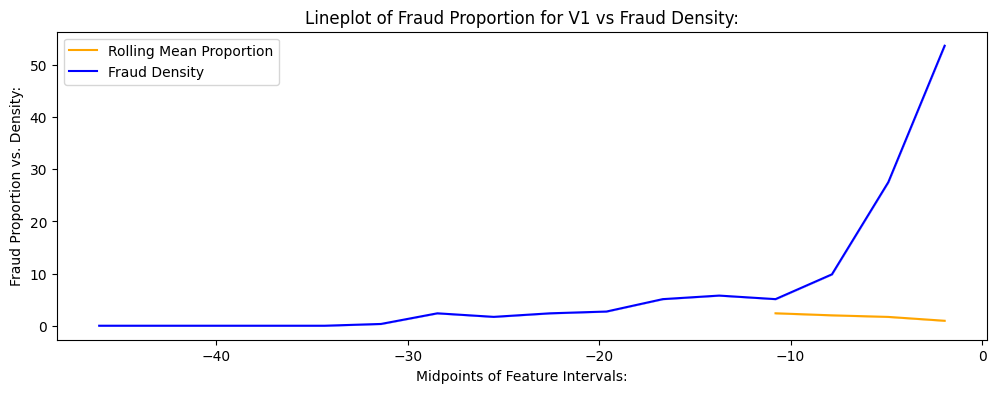

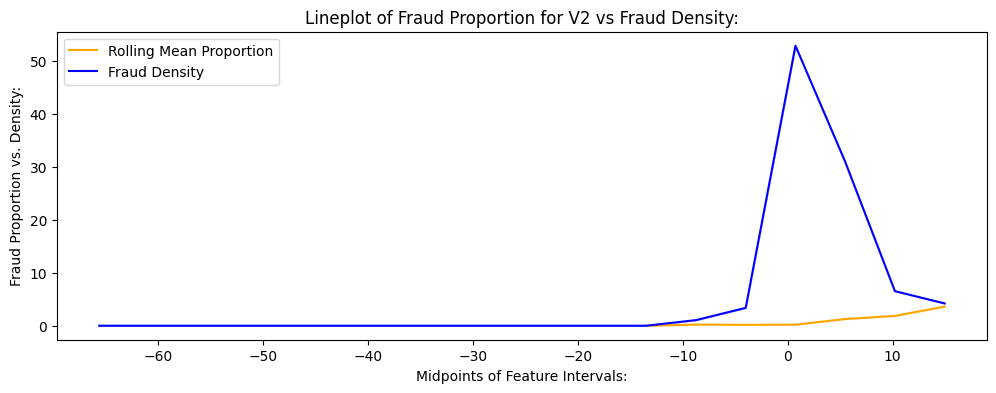

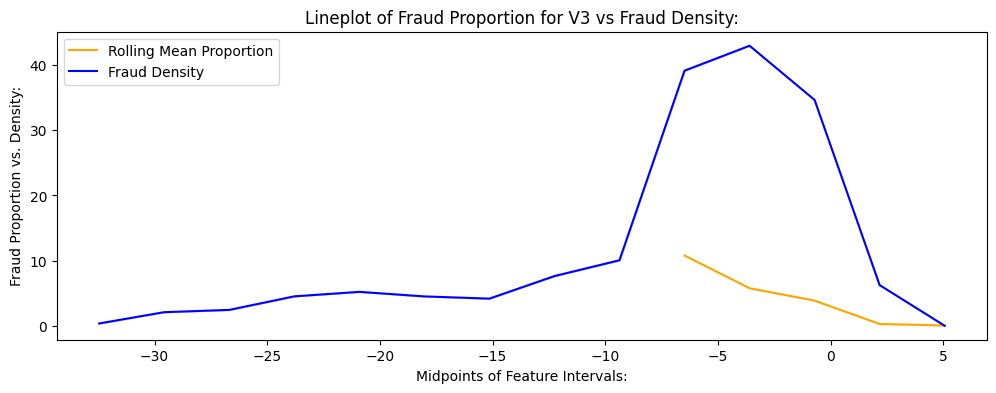

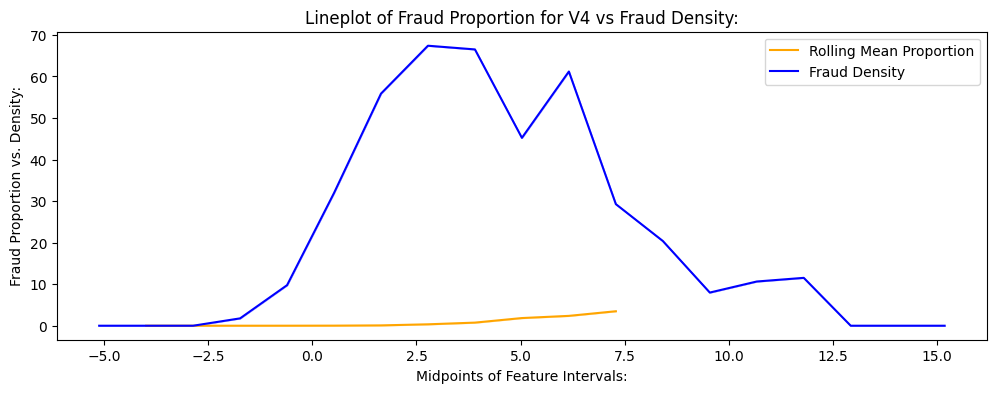

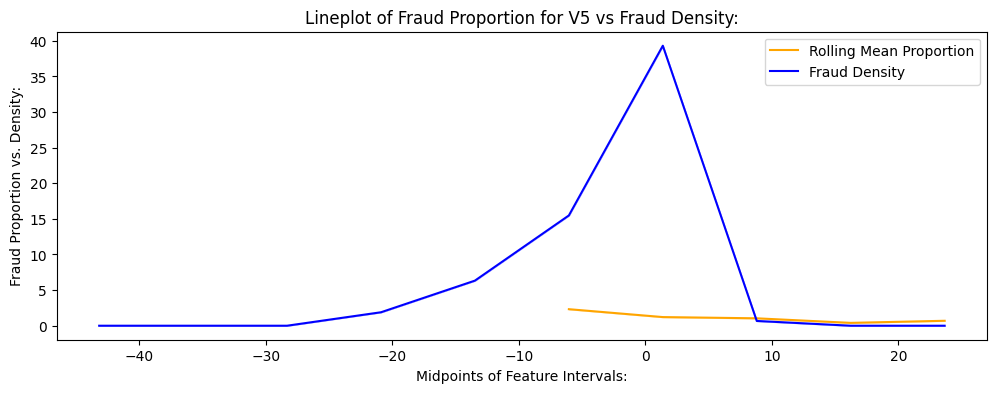

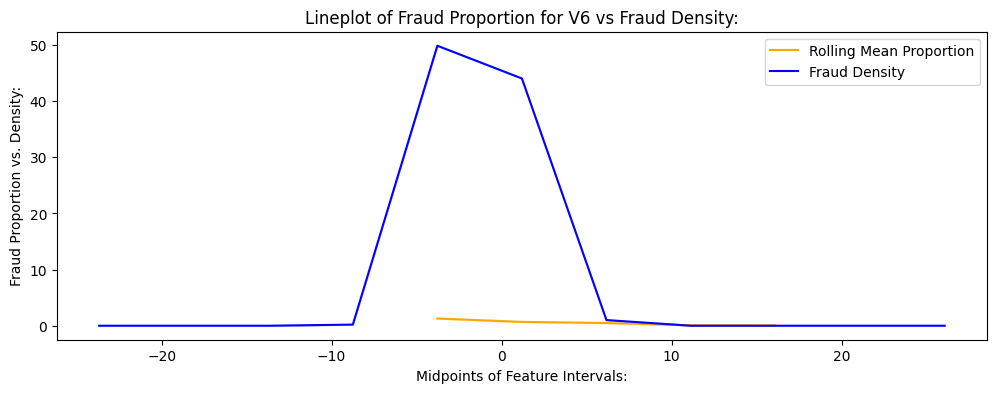

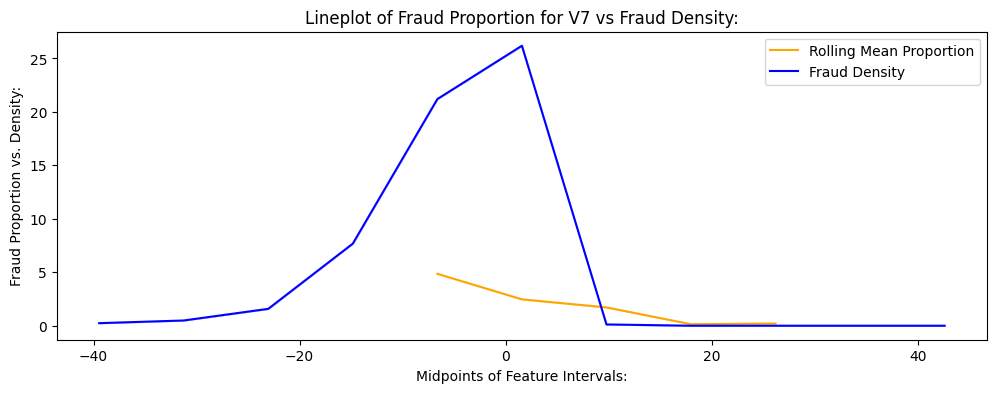

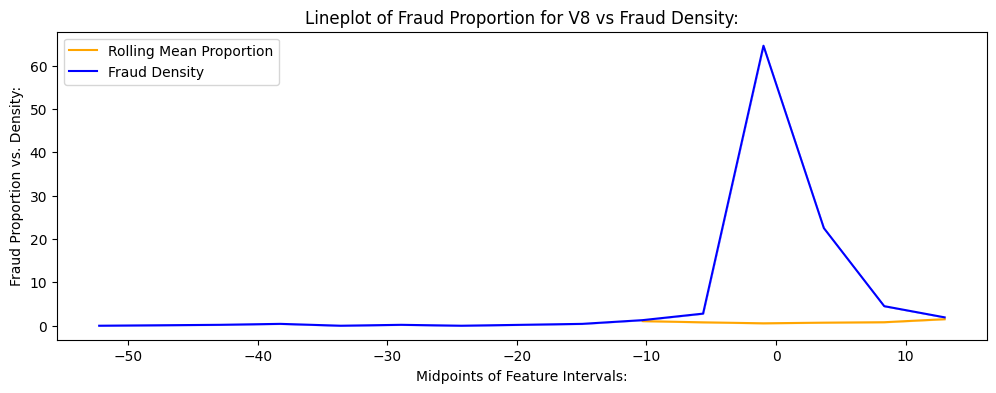

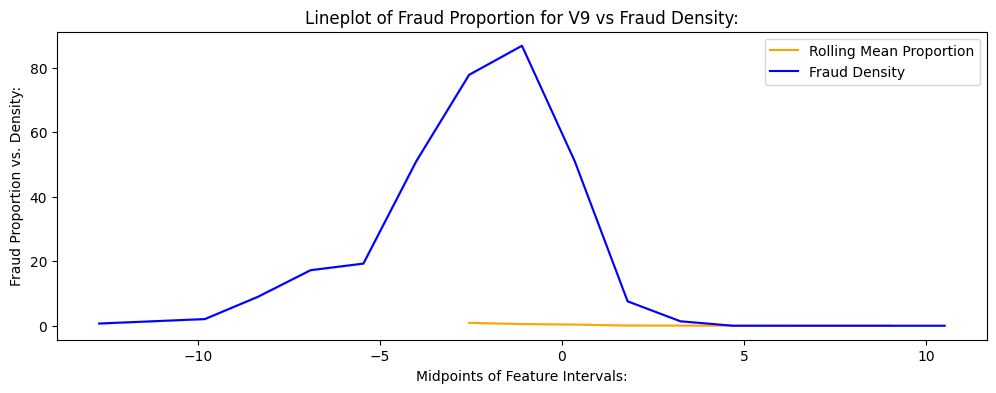

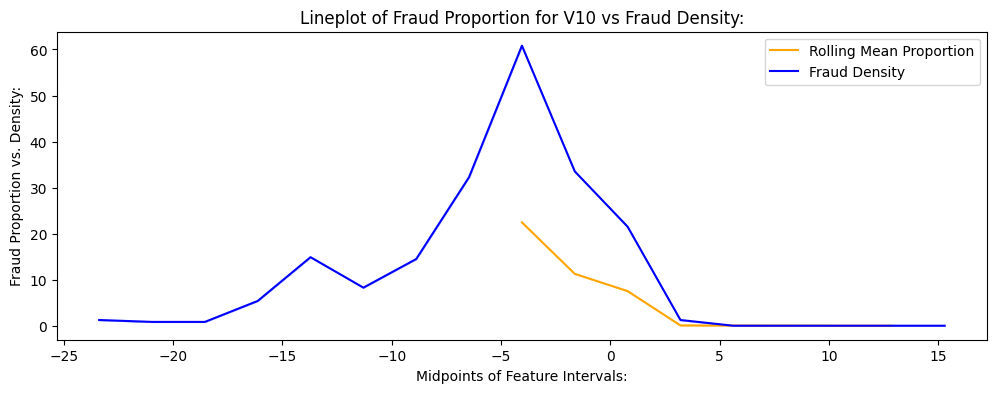

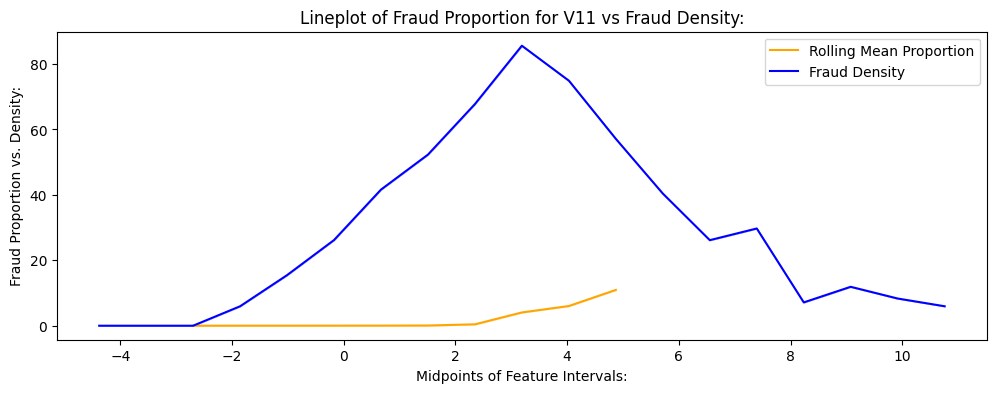

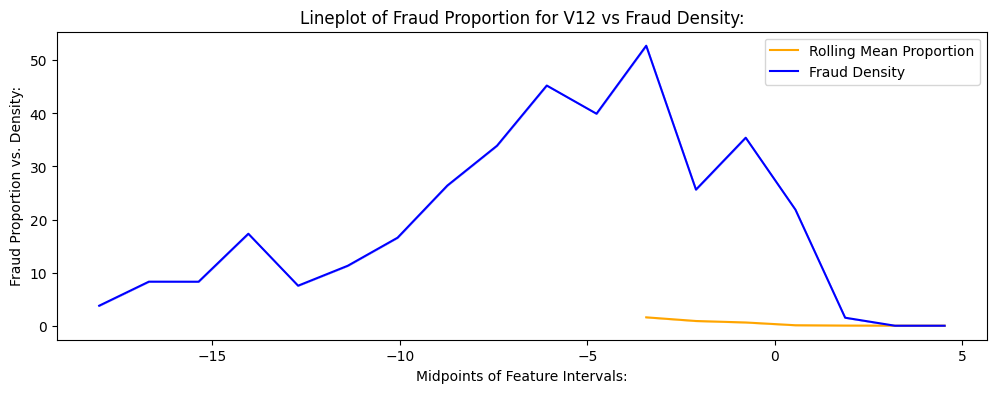

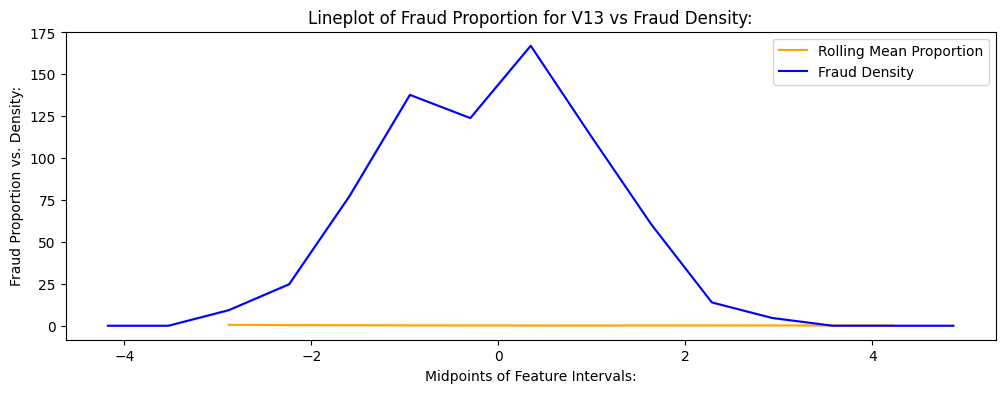

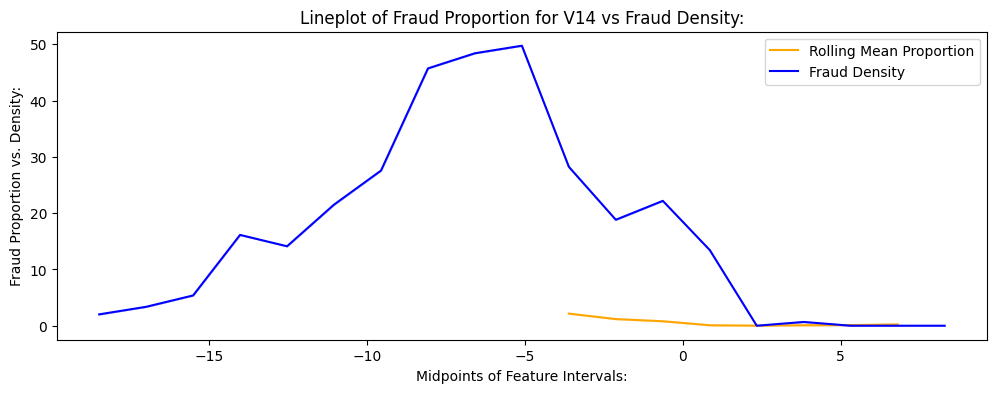

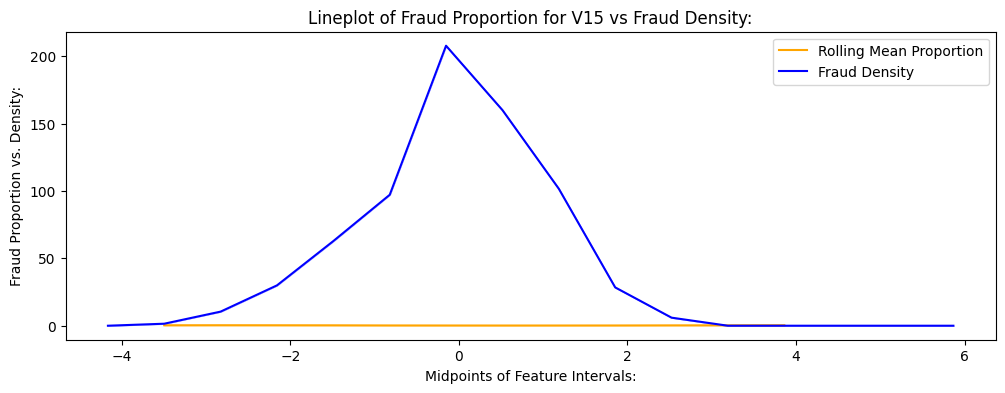

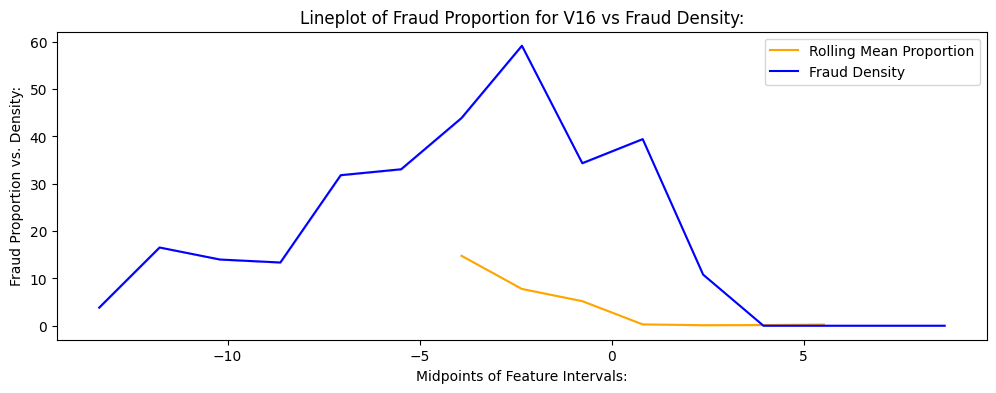

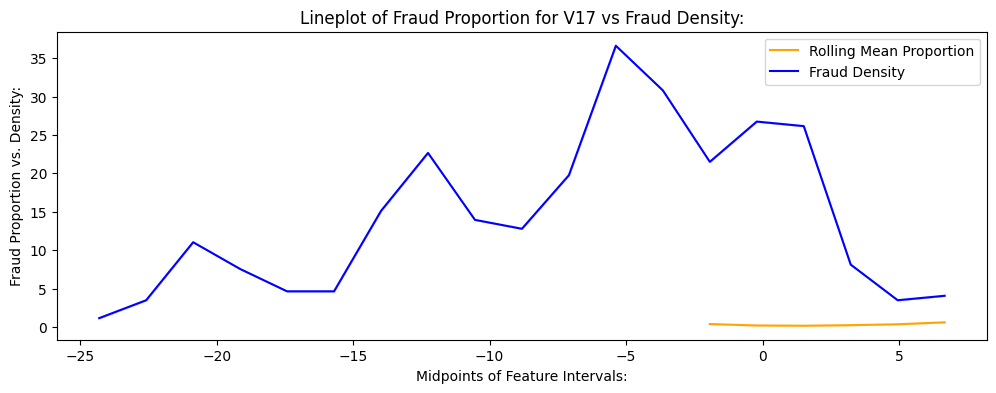

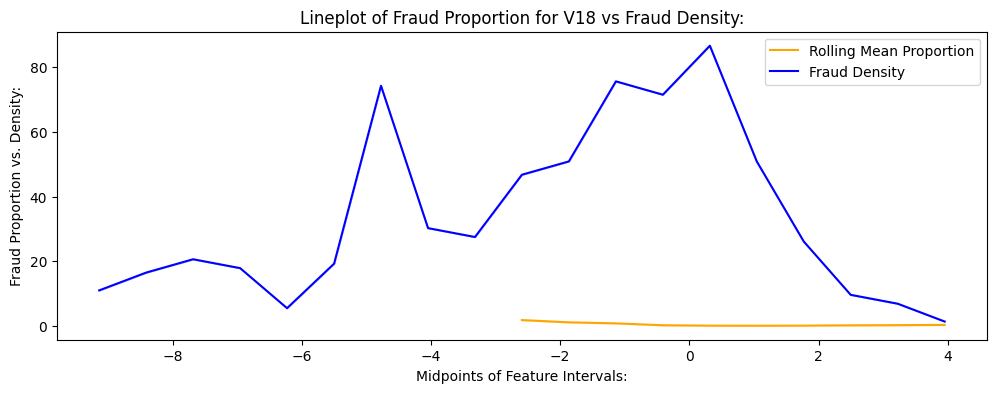

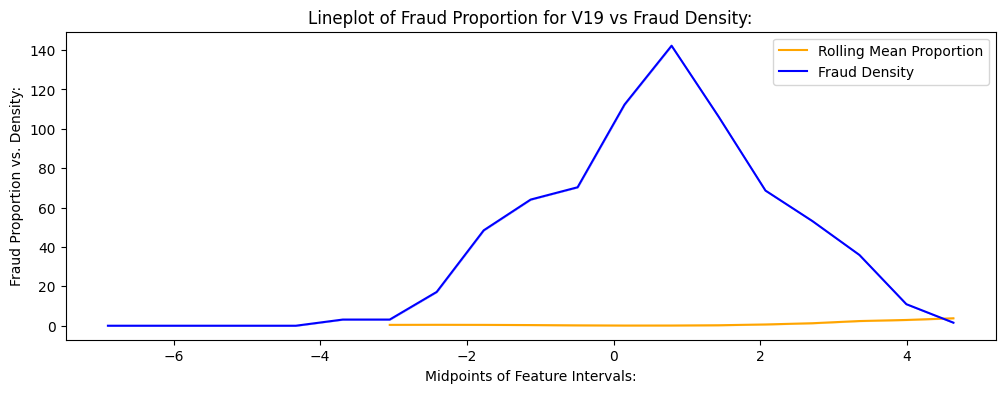

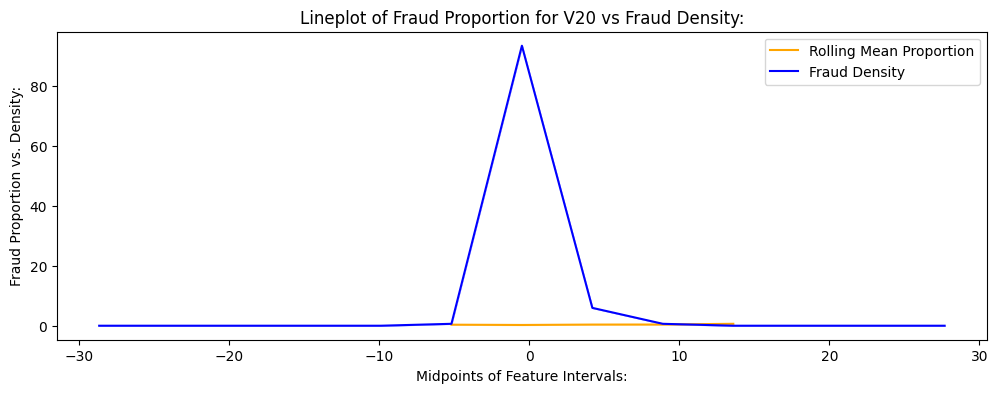

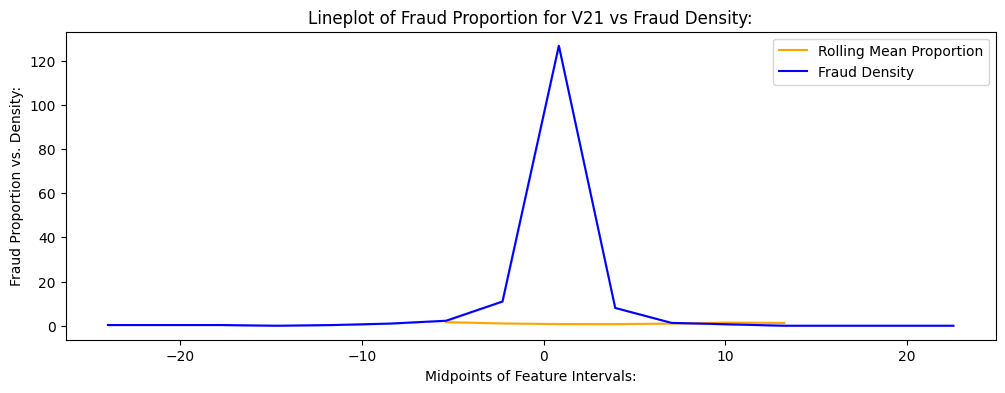

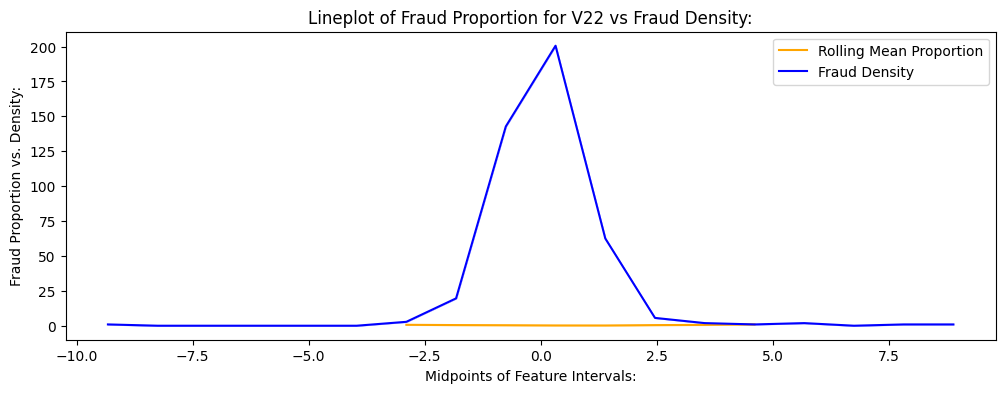

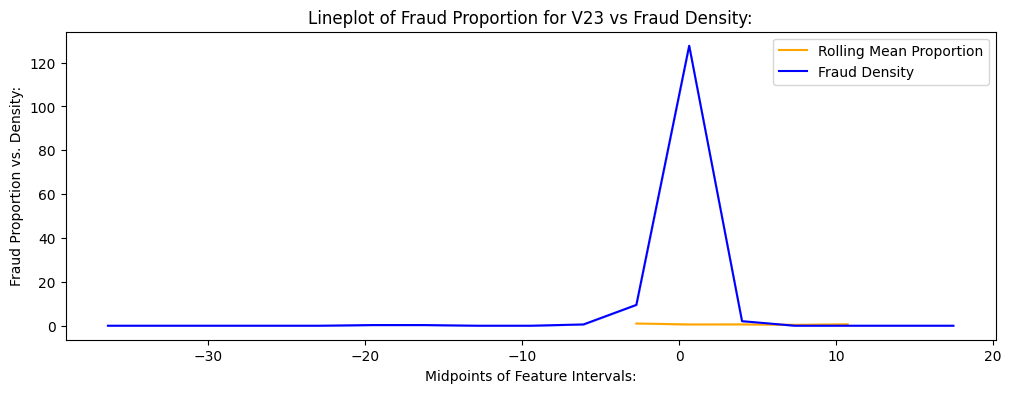

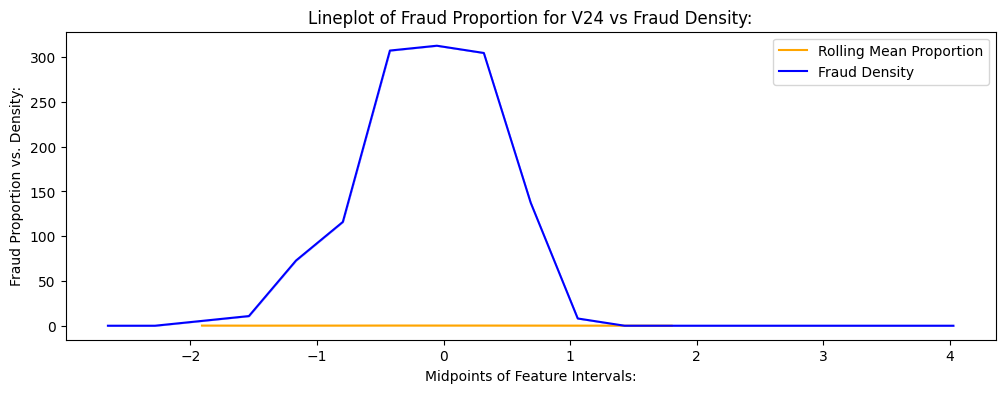

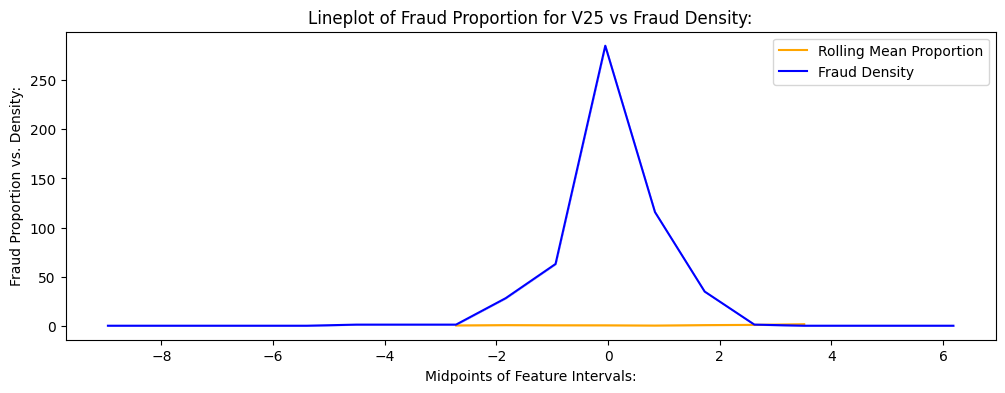

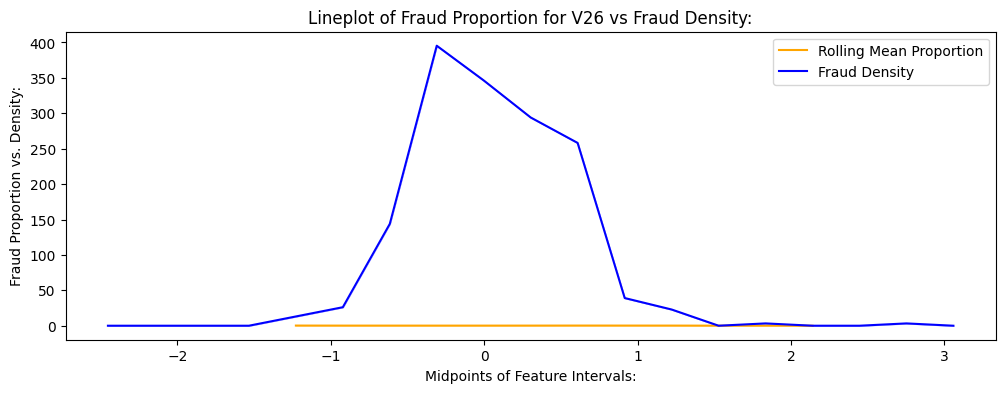

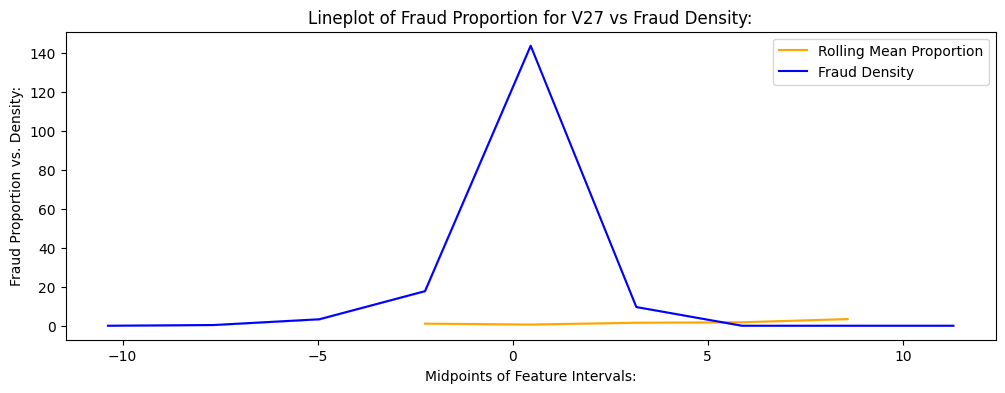

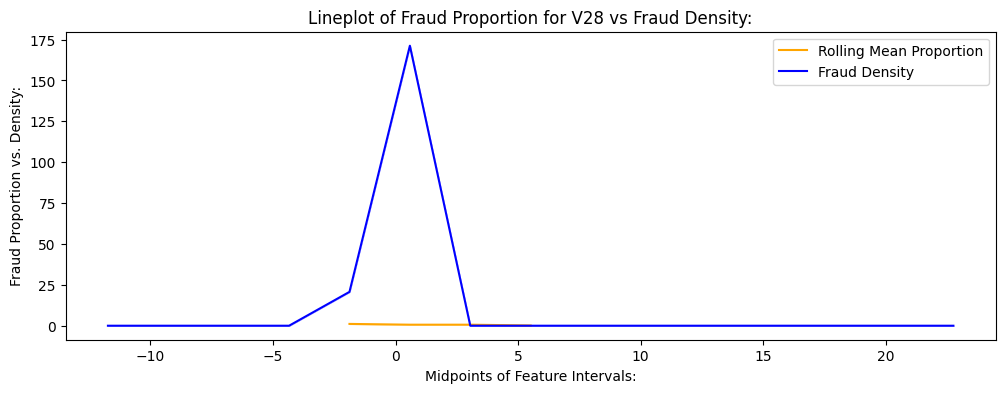

In [28]:
#creating a custom function to plot linegraphs for each feature in each df, comparing fraud density and proportion
def plot_pca_line(df, feature_name, x_col, y1_col, y2_col):
    
    plt.figure(figsize=(12, 4))

    sns.lineplot(df, x='interval_mid', y='rolling_mean_prop', color='orange', label='Rolling Mean Proportion')
    sns.lineplot(df, x='interval_mid', y='fraud_density', color='blue', label='Fraud Density')
    plt.title(f'Lineplot of Fraud Proportion for {feature_name} vs Fraud Density:')
    plt.xlabel('Midpoints of Feature Intervals:')
    plt.ylabel('Fraud Proportion vs. Density:')
    plt.legend()

for name, df in pca_dfs.items():
    (plot_pca_line(df, name, x_col='interval_mid', y1_col='rolling_mean_prop', y2_col='fraud_density'))

### Note on Line Graphs of Fraud Occurrences:
Feature-level analysis using equal-width binning revealed that fraud risk is often concentrated in specific value ranges rather than following linear trends. For example, V3 exhibits a sharp increase in fraud likelihood within a narrow negative range, while V7 shows a monotonic decrease in fraud risk as values increase. These patterns indicate strong non-linear relationships, motivating the use of tree-based models.

 Features such as V10 and V16 exhibit a strong monotonic relationship with fraud probability, suggesting they are highly informative predictors and suitable for both linear and non-linear models. Feature V11 exhibits a monotonic increasing relationship with fraud probability, indicating a stable and predictable influence on the target variable.

In [29]:
pca_features = ['V1','V2','V3','V4','V5','V6','V7','V8','V9','V10',
            'V11','V12','V13','V14','V15','V16','V17','V18','V19','V20',
            'V21','V22','V23','V24','V25','V26','V27','V28']

results = []

for feature in pca_features:
    
    corr, _ = spearmanr(v_features_raw[feature], v_features_raw['Class'])
    mi = mutual_info_classif(v_features_raw[feature].values.reshape(-1, 1), v_features_raw['Class'])[0]

    results.append({
        'feature': feature,
        'spearman': corr,
        'mutual_info': mi
    })



In [30]:
results_df = pd.DataFrame(results)
results_df['abs_spearman'] = abs(results_df['spearman'])
results_df_sorted = results_df.sort_values(by='abs_spearman', ascending=False)
results_df_sorted

,feature,spearman,mutual_info,abs_spearman
13,V14,-0.063191,0.007746,0.063191
3,V4,0.061652,0.004587,0.061652
11,V12,-0.061398,0.007220,0.061398
10,V11,0.058624,0.006450,0.058624
9,V10,-0.058024,0.007150,0.058024
2,V3,-0.057750,0.004583,0.057750
1,V2,0.049435,0.002920,0.049435
15,V16,-0.048252,0.005752,0.048252
8,V9,-0.048231,0.003854,0.048231
6,V7,-0.046583,0.003630,0.046583


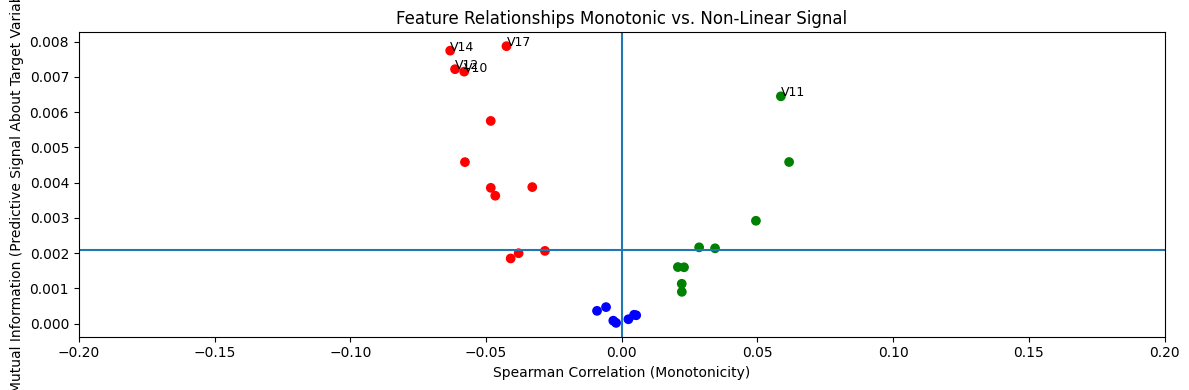

In [31]:
spearman_threshold = 0.02
mi_threshold = results_df_sorted['mutual_info'].median()

colours = []

for _, row in results_df_sorted.iterrows():
    if row['spearman'] > spearman_threshold:
        color = 'green'
    elif row['spearman'] < -spearman_threshold:
        color = 'red' 
    else:
        color = 'blue'
    colours.append(color)

plt.figure(figsize=(12, 4))

plt.scatter(x=results_df_sorted['spearman'], y=results_df_sorted['mutual_info'], c=colours)
plt.title('Feature Relationships Monotonic vs. Non-Linear Signal')
plt.xlabel('Spearman Correlation (Monotonicity)')
plt.ylabel('Mutual Information (Predictive Signal About Target Variable)')
plt.axvline(x=0)
plt.axhline(y=results_df_sorted['mutual_info'].median())
plt.xlim(-0.2, 0.2)

top_features = results_df_sorted.sort_values(by='mutual_info', ascending=False).head()

for _, row in top_features.iterrows():
    plt.text(row['spearman'], row['mutual_info'], row['feature'], fontsize=9)

plt.tight_layout()

### Feature Relationship Analysis: Monotonic vs Non-Linear Signal

The scatter plot comparing Spearman correlation and mutual information reveals clear structure in feature behavior.

1) Features with higher mutual information tend to exhibit strong monotonic relationships, either positive or negative. Several features show negative monotonic trends (decreasing fraud probability with increasing feature values), while others display positive monotonic relationships.
2) Features with near-zero Spearman correlation generally have low mutual information, indicating limited predictive value and weak association with the target variable.
3) These results suggest that, within the PCA-transformed feature space, fraud detection is primarily driven by directional (monotonic) relationships rather than complex non-linear patterns. While some non-linear behavior exists, it contributes less to overall predictive signal compared to monotonic features.

This analysis demonstrates that while PCA features lack direct interpretability, they retain structured relationships with fraud that can be effectively leveraged by appropriately chosen models.

# Model Training

### Reminder of Model Training Purpose:
The goal is to maximize fraud detection performance under class imbalance, prioritizing recall while maintaining precision.

### Splitting Data: 

In [32]:
x = transactions_df.drop(['Class', 'hours'], axis=1)
y = transactions_df['Class']

features_train, features_test, target_train, target_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=246)
features_train, features_val, target_train, target_val = train_test_split(features_train, target_train, test_size=0.2, stratify=target_train, random_state=246)

In [33]:
#creating an evaluation procedure for model training 
def evaluate_model(model, features_train, target_train, features_val, target_val):
    eval_stats = {}
    fig, axs = plt.subplots(1, 3, figsize=(20, 6))

    val_proba = model.predict_proba(features_val)[:, 1]
    preds_05 = (val_proba >= 0.5)

    #optimising for F1 score
    f1_thresholds = np.linspace(0, 1, 101)
    f1_scores = [metrics.f1_score(target_val, val_proba>=threshold) for threshold in f1_thresholds]
    f1_at_05 = metrics.f1_score(target_val, preds_05)

    best_index = np.argmax(f1_scores)
    best_f1 = f1_scores[best_index]
    best_threshold = f1_thresholds[best_index]

    eval_stats['best_threshold'] = best_threshold

    print("Best threshold:", best_threshold)
    print("Best F1:", best_f1)
    print("Last 10 F1 scores:", f1_scores[-10:])
    print("Last 10 thresholds:", f1_thresholds[-10:])
       
    #Optimised F1 Score Plotting 
    ax = axs[0]
    ax.plot(f1_thresholds, f1_scores, label='Validation F1')
    ax.scatter(best_threshold, best_f1, marker='X', s=100, label=f'{best_f1:.2f} @ {best_threshold:.2f}')
    ax.scatter(0.5, f1_at_05, marker='X', s=100, label=f'0.5 {f1_at_05:.2f}')
    ax.axvline(best_threshold, linestyle='--')

    ax.set_xlabel('Threshold')
    ax.set_ylabel('F1')
    ax.legend(loc='upper left')
    
    ax.set_title('F1 vs. Threshold (Validation)')

    for split, features, target in (('train', features_train, target_train), ('val', features_val, target_val)):

        eval_stats[split] = {}
        pred_proba = model.predict_proba(features)[:, 1]
        pred_target = (pred_proba >= best_threshold)

        #F1 
        f1 = metrics.f1_score(target, pred_target)
        eval_stats[split]['F1'] = f1 

        #Precision and Recall 
        precision_scores = metrics.precision_score(target, pred_target)
        recall_scores = metrics.recall_score(target, pred_target)
        eval_stats[split]['Precision'] = precision_scores
        eval_stats[split]['Recall'] = recall_scores

        #ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)
        eval_stats[split]['ROC AUC'] = roc_auc

        #PRC
        precision_curve, recall_curve, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[split]['APS'] = aps

        if split == 'train':
            color = 'blue'
        else:
            color = 'green'

        #ROC curve Plotting
        ax2 = axs[1]
        ax2.plot(fpr, tpr, color=color, label=f'{split}, ROC AUC: {roc_auc:.2f}')
        idx = np.argmin(np.abs(roc_thresholds - best_threshold))
        ax2.scatter(fpr[idx], tpr[idx], color=color, marker='X')
        ax2.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax2.set_xlim([-0.02, 1.02])
        ax2.set_ylim([-0.02, 1.02])
        ax2.set_xlabel('FPR')
        ax2.set_ylabel('TPR')
        ax2.legend(loc='lower center')
        ax2.set_title('ROC Curve')

        #PRC Plotting
        ax3 = axs[2]
        ax3.plot(recall_curve, precision_curve, color=color, label=f'{split}, AP={aps:.2f}')

        if len(pr_thresholds) > 0:
            idx = np.argmin(np.abs(pr_thresholds - best_threshold))
            ax3.scatter(recall_curve[idx], precision_curve[idx], color=color, marker='X')

        ax3.set_xlabel('Recall')
        ax3.set_ylabel('Precision')
        ax3.legend(loc='upper left')
        ax3.set_title('PRC')

        
    plt.tight_layout()

    best_threshold = eval_stats.pop('best_threshold')
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('F1', 'Precision', 'Recall', 'APS', 'ROC AUC'))

    print(df_eval_stats)

    return eval_stats

### Notes On Evaluation Procedure: 
- This evaluation procedure optimizes the classification threshold using the validation set by maximizing the F1 score, rather than relying on the default 0.5 threshold. 
- It then applies this optimal threshold to both the training and validation sets to compute performance metrics including F1, precision, and recall.
- In addition, threshold-independent metrics such as ROC-AUC and Average Precision Score (APS) are calculated using predicted probabilities to assess overall model quality. 
- The procedure also generates F1, ROC, and precision-recall curves, with the selected threshold highlighted to illustrate the model’s operating point and the trade-offs between precision and recall.
- Overall, this approach ensures that model performance is evaluated in a way that accounts for class imbalance and reflects realistic decision-making.

## Logistic Regression (baseline):

c:\Users\micha\Credit Fraud\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Best threshold: 0.99
Best F1: 0.6787878787878788
Last 10 F1 scores: [0.4306569343065693, 0.46825396825396826, 0.5042735042735043, 0.5267857142857143, 0.5412844036697247, 0.5771144278606966, 0.6086956521739131, 0.632768361581921, 0.6787878787878788, 0.1686746987951807]
Last 10 thresholds: [0.91 0.92 0.93 0.94 0.95 0.96 0.97 0.98 0.99 1.  ]
           train   val
F1          0.74  0.68
Precision   0.67  0.63
Recall      0.83  0.74
APS         0.73  0.68
ROC AUC     0.99  0.96


{'train': {'F1': 0.7393225331369662,
  'Precision': 0.6657824933687002,
  'Recall': 0.8311258278145696,
  'ROC AUC': 0.9875093803945717,
  'APS': 0.7314107500308049},
 'val': {'F1': 0.6787878787878788,
  'Precision': 0.6292134831460674,
  'Recall': 0.7368421052631579,
  'ROC AUC': 0.9621910856134156,
  'APS': 0.6823845149980357}}

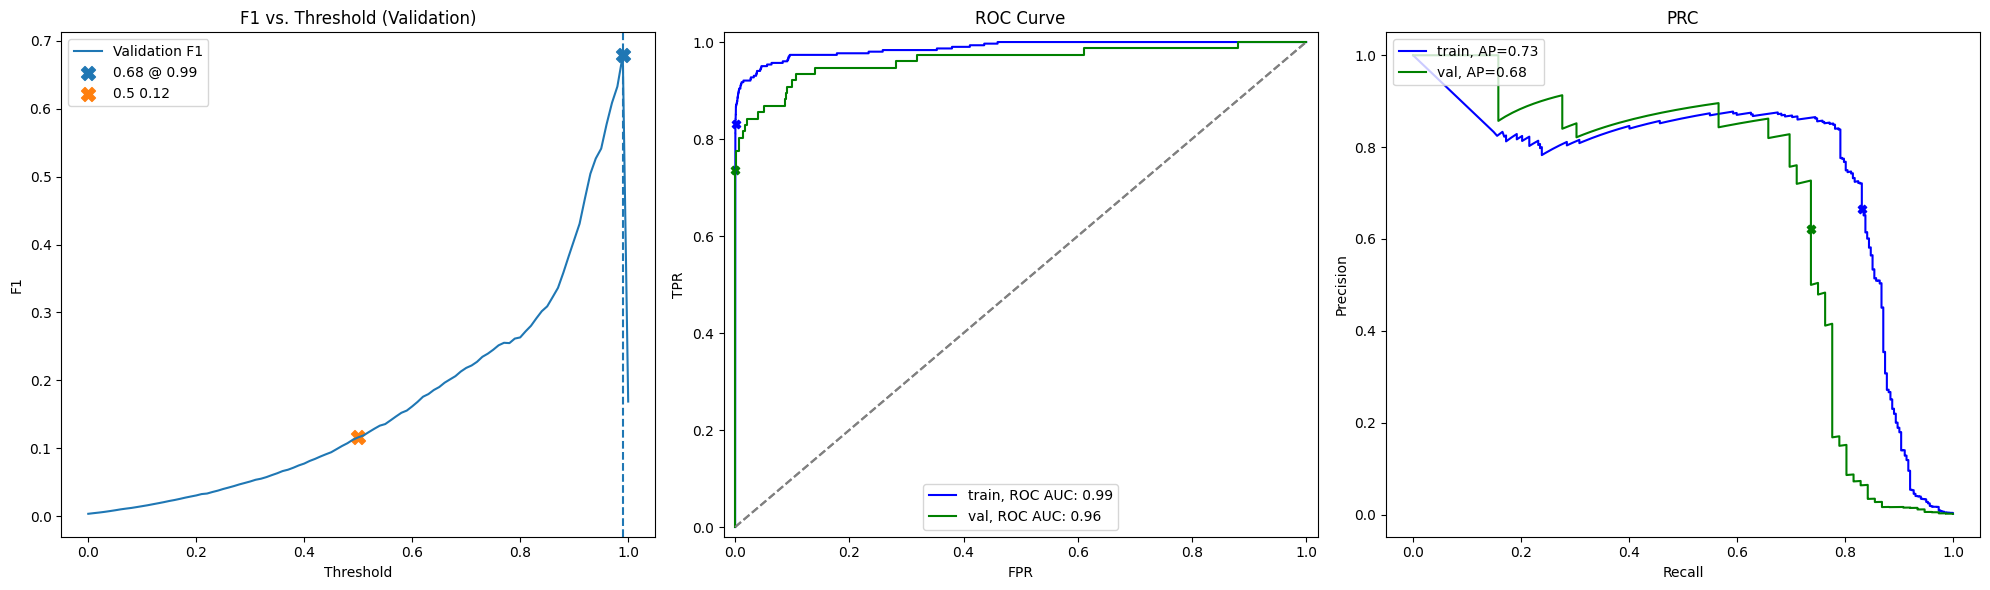

In [34]:
lr_model = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=246)
lr_model.fit(features_train, target_train)
evaluate_model(lr_model, features_train, target_train, features_val, target_val)

## Random Forest (With Balanced Class Weight):

Best threshold: 0.73
Best F1: 0.7777777777777778
Last 10 F1 scores: [0.7230769230769231, 0.7230769230769231, 0.71875, 0.71875, 0.7086614173228346, 0.6984126984126984, 0.6446280991735537, 0.5789473684210527, 0.49056603773584906, 0.0]
Last 10 thresholds: [0.91 0.92 0.93 0.94 0.95 0.96 0.97 0.98 0.99 1.  ]
           train   val
F1          0.83  0.78
Precision   0.80  0.82
Recall      0.86  0.74
APS         0.76  0.67
ROC AUC     0.99  0.96


{'train': {'F1': 0.8301282051282052,
  'Precision': 0.8043478260869565,
  'Recall': 0.8576158940397351,
  'ROC AUC': 0.994592669676917,
  'APS': 0.7592829634886805},
 'val': {'F1': 0.7777777777777778,
  'Precision': 0.8235294117647058,
  'Recall': 0.7368421052631579,
  'ROC AUC': 0.961554965856831,
  'APS': 0.6665761803271325}}

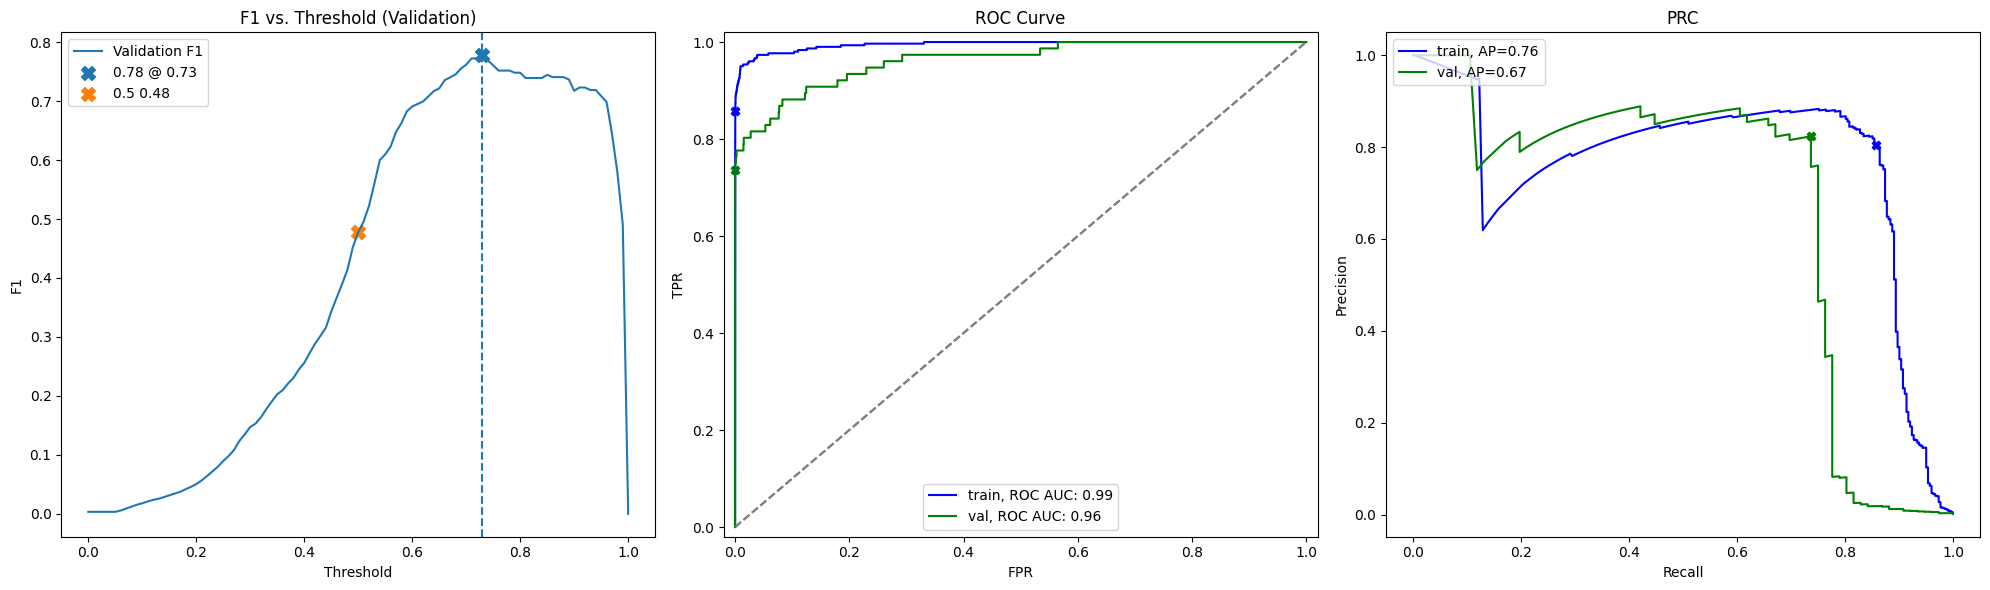

In [35]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=4, class_weight='balanced', random_state=246)
rf_model.fit(features_train, target_train)
evaluate_model(rf_model, features_train, target_train, features_val, target_val)

## Random Forest Model (No Balancing):

Best threshold: 0.15
Best F1: 0.7638888888888888
Last 10 F1 scores: [0.29213483146067415, 0.23255813953488372, 0.21176470588235294, 0.1686746987951807, 0.12345679012345678, 0.025974025974025976, 0.0, 0.0, 0.0, 0.0]
Last 10 thresholds: [0.91 0.92 0.93 0.94 0.95 0.96 0.97 0.98 0.99 1.  ]
           train   val
F1          0.83  0.76
Precision   0.81  0.81
Recall      0.84  0.72
APS         0.85  0.72
ROC AUC     0.97  0.93


{'train': {'F1': 0.8292682926829268,
  'Precision': 0.8146964856230032,
  'Recall': 0.8443708609271523,
  'ROC AUC': 0.9740644465163528,
  'APS': 0.8478087530711198},
 'val': {'F1': 0.7638888888888888,
  'Precision': 0.8088235294117647,
  'Recall': 0.7236842105263158,
  'ROC AUC': 0.9348450492404887,
  'APS': 0.7182561243811548}}

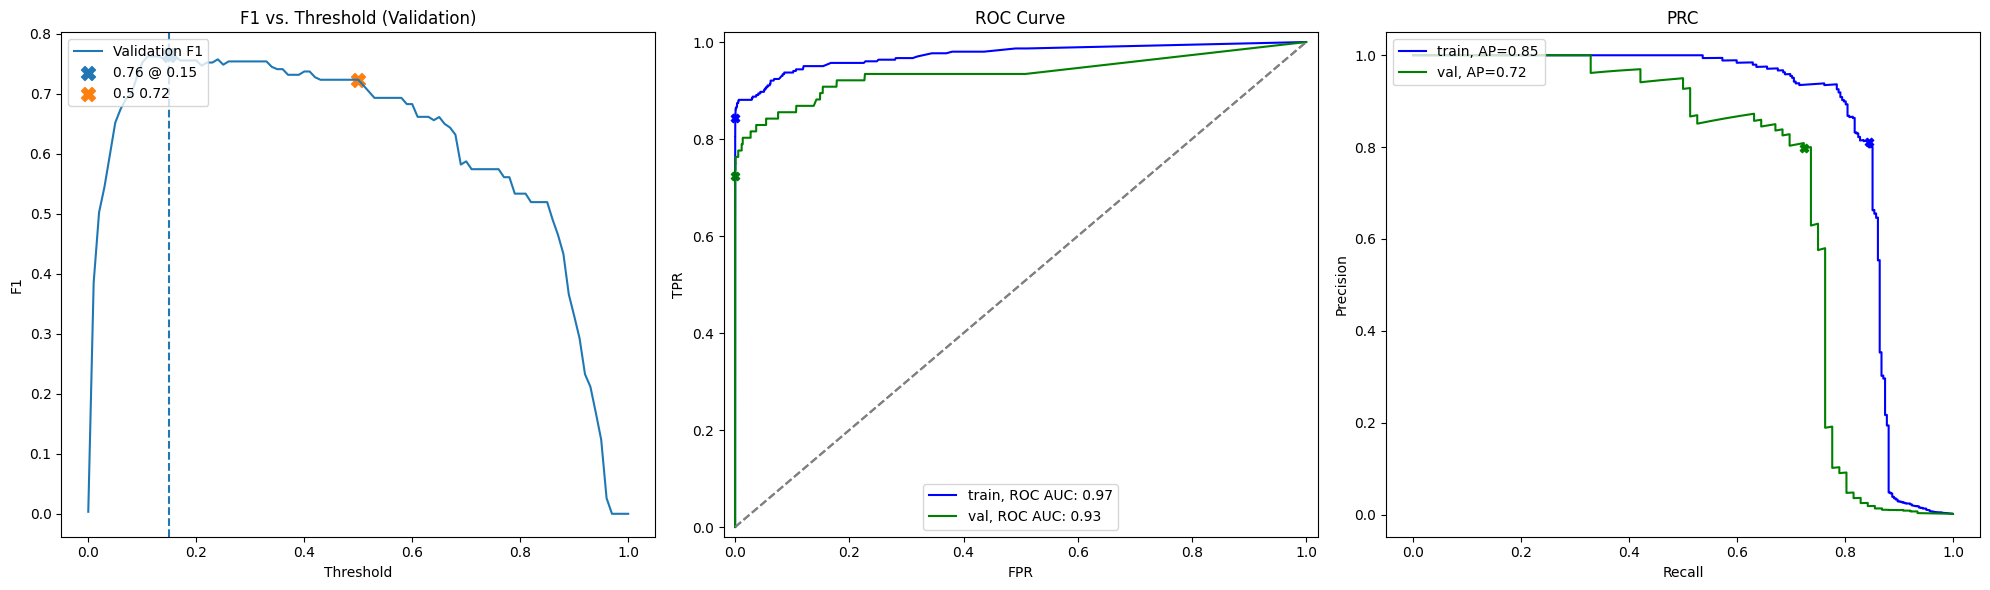

In [36]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=246)
rf_model.fit(features_train, target_train)
evaluate_model(rf_model, features_train, target_train, features_val, target_val)

### Conclusions on Class Balanced and Non-Class Balanced Random Forest Models:
Introducing class weighting in the Random Forest model slightly improved F1 score but resulted in a decrease in Average Precision Score and a significant shift in the optimal classification threshold. This suggests that class weighting distorted the model’s probability estimates, reducing its ability to rank fraudulent transactions effectively. As a result, the unweighted model was preferred due to its better balance between ranking performance and classification stability

## Gradient Boosting Models (LightGBM and XGBoost)

### LightGBM:

[LightGBM] [Info] Number of positive: 302, number of negative: 181282
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007116 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 181584, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001663 -> initscore=-6.397382
[LightGBM] [Info] Start training from score -6.397382
Best threshold: 0.15
Best F1: 0.7746478873239436
Last 10 F1 scores: [0.7154471544715447, 0.7154471544715447, 0.7049180327868853, 0.6722689075630253, 0.6666666666666666, 0.6666666666666666, 0.6194690265486725, 0.6126126126126126, 0.5098039215686274, 0.0]
Last 10 thresholds: [0.91 0.92 0.93 0.94 0.95 0.96 0.97 0.98 0.99 1.  ]
           train   val
F1          0.97  0.77
Precision   0.95  0.83
Recall      1.00  0.72
APS         1.00  0.74
ROC AUC     1.00  0.96


{'train': {'F1': 0.9741935483870968,
  'Precision': 0.949685534591195,
  'Recall': 1.0,
  'ROC AUC': 0.9999990501791106,
  'APS': 0.9994273500748732},
 'val': {'F1': 0.7746478873239436,
  'Precision': 0.8333333333333334,
  'Recall': 0.7236842105263158,
  'ROC AUC': 0.9611734682027222,
  'APS': 0.739563892335217}}

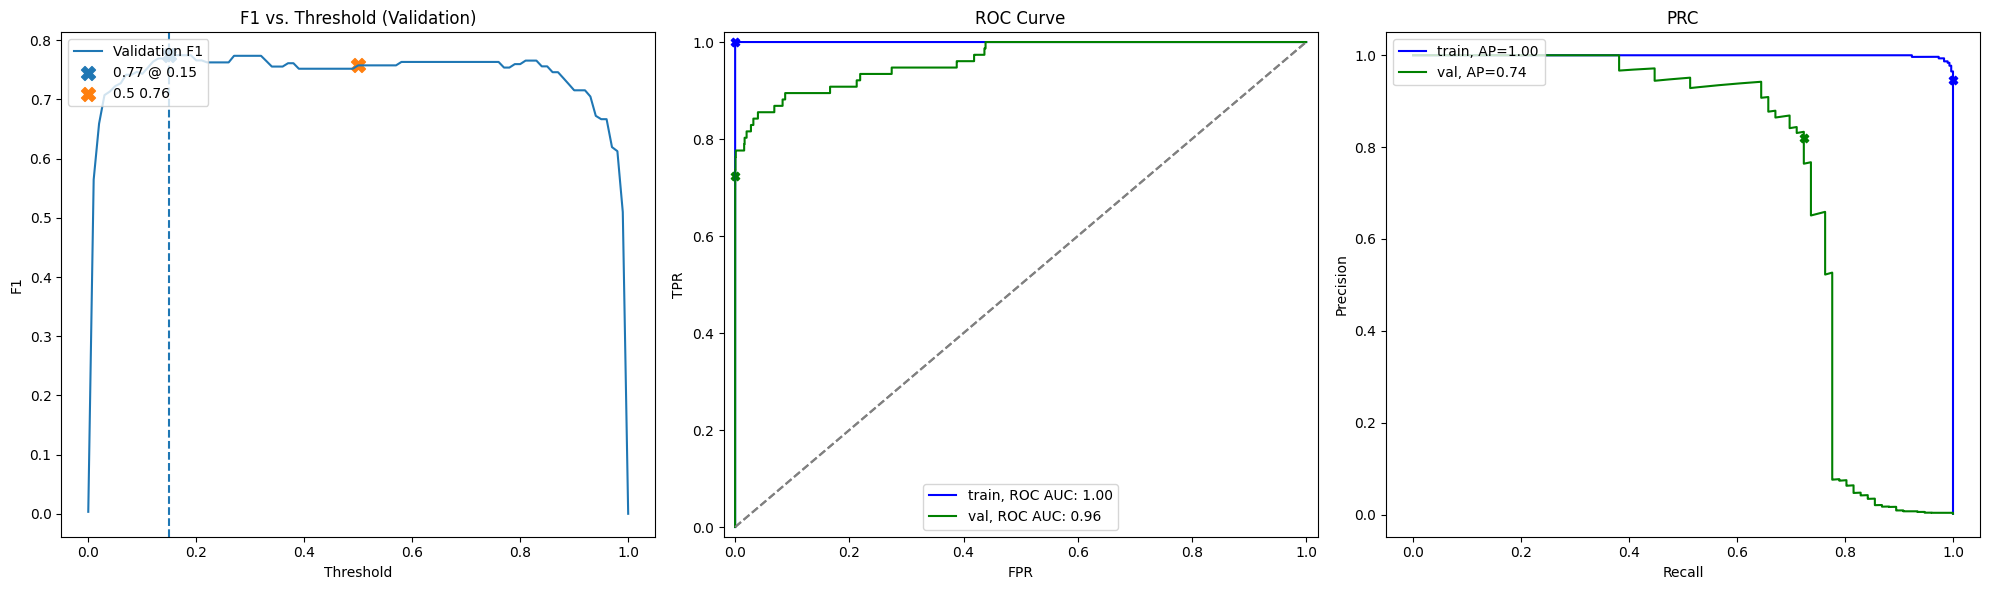

In [43]:
lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=7,
    max_depth=5,
    min_child_samples=150,
    subsample=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=246
)
lgbm.fit(features_train, target_train)
evaluate_model(lgbm, features_train, target_train, features_val, target_val)

### Conclusions on LightGBM Model:
After increasing regularization by reducing the number of leaves and increasing the minimum child samples, the LightGBM model achieved strong and stable performance, with a validation F1 score of approximately 0.77 and an APS of 0.74. The reduction in training performance (F1 ≈ 0.97) indicates that overfitting has been effectively mitigated.

The model maintains a balanced trade-off between precision (0.83) and recall (0.72), and the optimal threshold lies in a stable mid-range, suggesting well-behaved probability estimates. Overall, this configuration provides a more reliable and generalizable model while preserving strong predictive performance.

### XGBoost:

Best threshold: 0.38
Best F1: 0.8175182481751825
Last 10 F1 scores: [0.7317073170731707, 0.7107438016528925, 0.6890756302521008, 0.6724137931034483, 0.6491228070175439, 0.625, 0.6, 0.5333333333333333, 0.3829787234042553, 0.0]
Last 10 thresholds: [0.91 0.92 0.93 0.94 0.95 0.96 0.97 0.98 0.99 1.  ]
           train   val
F1          0.95  0.82
Precision   0.99  0.92
Recall      0.92  0.74
APS         0.99  0.76
ROC AUC     1.00  0.97


{'train': {'F1': 0.9535283993115319,
  'Precision': 0.992831541218638,
  'Recall': 0.9172185430463576,
  'ROC AUC': 0.9999807661269906,
  'APS': 0.9908919600611203},
 'val': {'F1': 0.8175182481751825,
  'Precision': 0.9180327868852459,
  'Recall': 0.7368421052631579,
  'ROC AUC': 0.9693887327542157,
  'APS': 0.7563128298270471}}

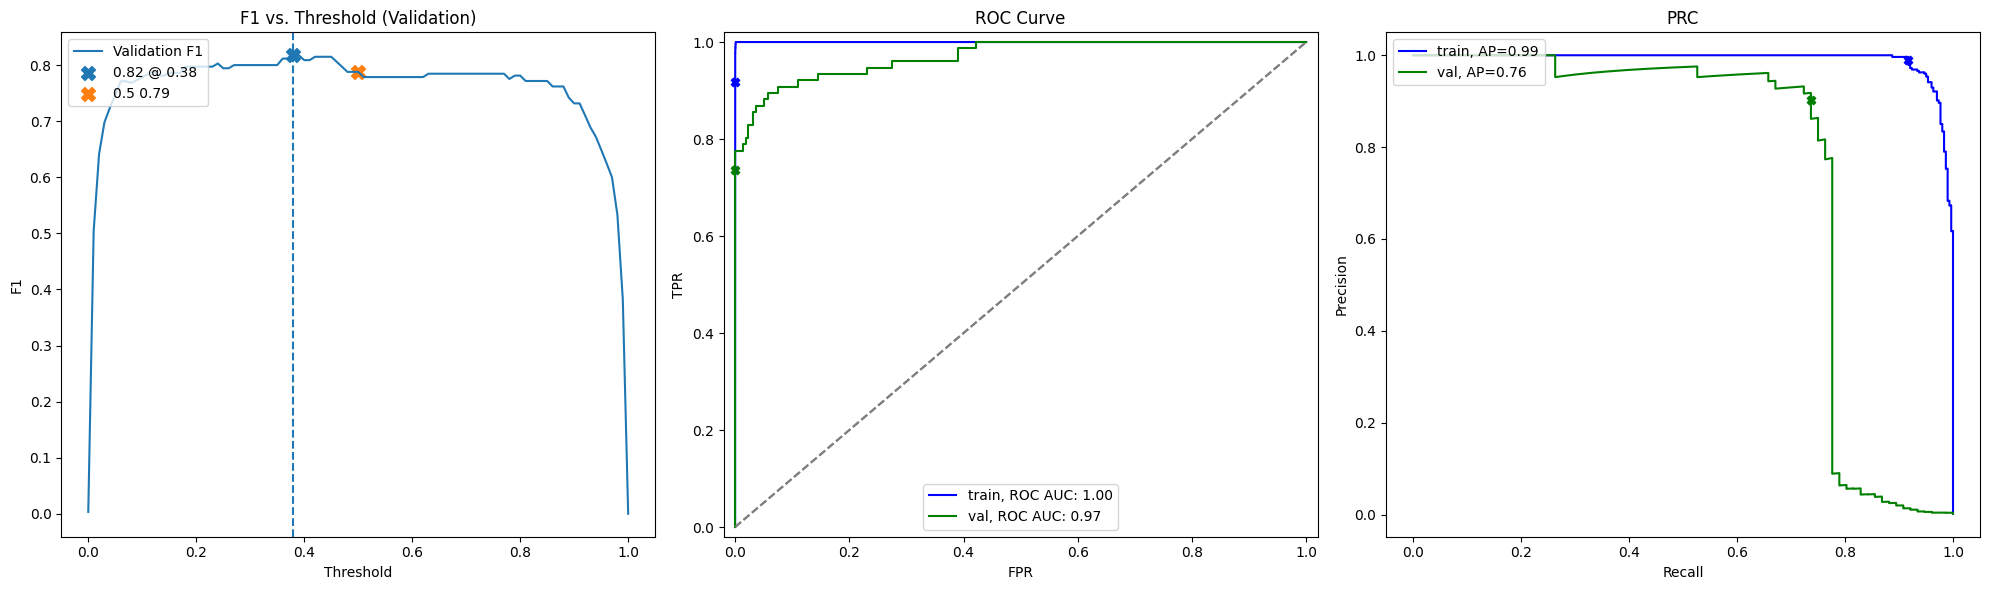

In [45]:
xgb = XGBClassifier(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    gamma=0.1,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=246
)
xgb.fit(features_train, target_train)
evaluate_model(xgb, features_train, target_train, features_val, target_val)

### Conclusions on XGBoost Model:
The XGBoost model demonstrates strong and stable performance across all evaluation metrics. The F1 score peaks at approximately 0.82 at a threshold of around 0.38, indicating a well-balanced trade-off between precision and recall. The ROC-AUC of 0.97 confirms strong class separation, while the precision-recall curve shows consistently high precision across a broad range of recall values, resulting in an APS of 0.76.

The model’s performance at the selected threshold achieves high precision ( roughly 0.92) while maintaining solid recall ( roughly 0.74), making it well-suited for fraud detection tasks where minimizing false positives is important without significantly reducing detection capability.

## Final Testing on Best Performing Model (XGBoost):

In [46]:
features_final = pd.concat([features_train, features_val])
target_final = pd.concat([target_train, target_val])

xgb.fit(features_final, target_final)

test_proba = xgb.predict_proba(features_test)[:, 1]
test_pred = (test_proba >= 0.38) #best threshold found in XGBoost model

f1 = metrics.f1_score(target_test, test_pred)
precision = metrics.precision_score(target_test, test_pred)
recall = metrics.recall_score(target_test, test_pred)
roc_auc = metrics.roc_auc_score(target_test, test_proba)
aps = metrics.average_precision_score(target_test, test_proba)

print(f'Final F1 Score: {f1:.2f}')
print(f'Final Recall: {recall:.2f}')
print(f'Final Precision: {precision:.2f}')
print(f'Final ROC-AUC: {roc_auc:.2f}')
print(f'Final APS: {aps:.2f}')

Final F1 Score: 0.86
Final Recall: 0.78
Final Precision: 0.95
Final ROC-AUC: 0.98
Final APS: 0.83


Text(0.5, 1.0, 'Test Set PRC')

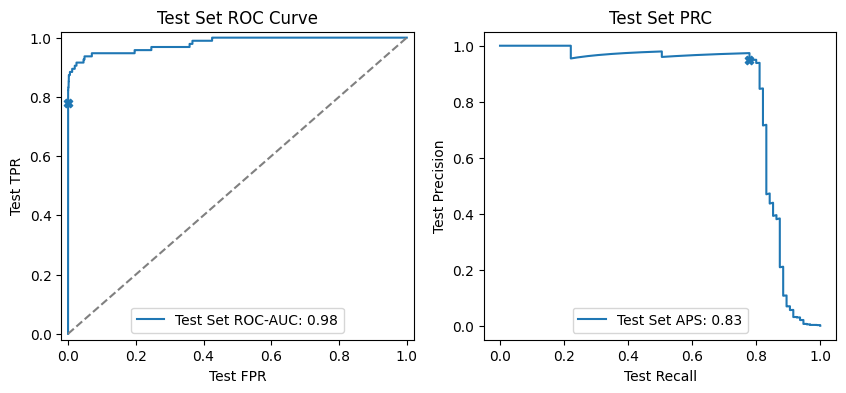

In [48]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
#ROC
fpr, tpr, roc_thresholds = metrics.roc_curve(target_test, test_proba)
#PRC
precision_curve, recall_curve, pr_thresholds = metrics.precision_recall_curve(target_test, test_proba)
final_threshold = 0.38
#ROC curve Plotting
ax = axs[0]
ax.plot(fpr, tpr, label=f'Test Set ROC-AUC: {roc_auc:.2f}')
idx = np.argmin(np.abs(roc_thresholds - final_threshold))
ax.scatter(fpr[idx], tpr[idx], marker='X')
ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_xlabel('Test FPR')
ax.set_ylabel('Test TPR')
ax.legend(loc='lower center')
ax.set_title('Test Set ROC Curve')

#PRC Curve Plotting
ax2 = axs[1]
ax2.plot(recall_curve, precision_curve, label=f'Test Set APS: {aps:.2f}')

if len(pr_thresholds > 0):
    idx = np.argmin(np.abs(pr_thresholds - final_threshold))

ax2.scatter(recall_curve[idx], precision_curve[idx], marker='X')
ax2.set_xlabel('Test Recall')
ax2.set_ylabel('Test Precision')
ax2.legend(loc='lower center')
ax2.set_title('Test Set PRC')


In [51]:
#creating a confusion matrix for final visualisation 
cm = confusion_matrix(target_test, test_pred)
print(cm)

[[56647     4]
 [   21    74]]


Text(0.5, 1.0, 'Confusion Matrix (test set)')

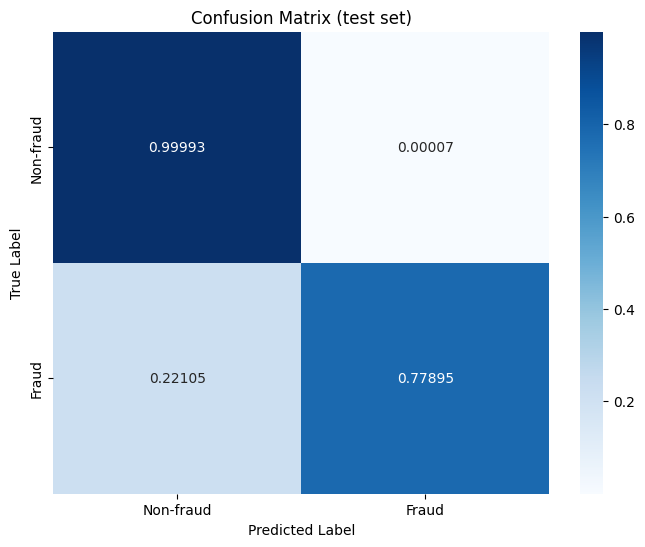

In [56]:
plt.figure(figsize=(8, 6))
labels = ['Non-fraud', 'Fraud']
normalised_cm = cm / cm.sum(axis=1, keepdims=True)

sns.heatmap(normalised_cm, annot=True, fmt='.5f', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (test set)')


### Conclusions on Confusion Matrix:
The confusion matrix is set up as such: True negatives; top right (actually non-fraudulent transactions), False positives; top left (transactions flagged as fraud but are actually clean), False negatives; bottom left (fraudulent transactions that were not flagged as fraud) and true positives; bottom right (actually fraudulent transactions that were flagged as fraud). 

The confusion matrix confirms that the model performs exceptionally well at identifying legitimate transactions, with a negligible false positive rate. This results in very high precision, meaning that flagged transactions are highly likely to be fraudulent.

At the same time, the model successfully detects approximately 78% of fraudulent transactions, though around 22% are missed. This reflects a deliberate trade-off favoring precision over recall, ensuring minimal disruption to legitimate users while still capturing the majority of fraud cases.

Overall, the model provides a strong and practical balance between fraud detection and false alarm reduction, making it well-suited for real-world deployment where excessive false positives can be costly.

# Final Conclusion

This project developed  machine learning models to detect fraudulent transactions in a highly imbalanced dataset. Initial exploratory analysis highlighted the severity of class imbalance and confirmed that the anonymized PCA features already capture meaningful signal related to fraud. Additional variables such as transaction amount and time showed limited standalone predictive power but were incorporated into the modeling process.

A range of models were evaluated, starting with logistic regression as a baseline, followed by Random Forest and gradient boosting approaches. Logistic regression underperformed due to its inability to capture complex patterns in the data. Random Forest provided a strong improvement, demonstrating better balance between precision and recall. Further gains were achieved using boosting methods, with LightGBM and XGBoost offering enhanced performance through more effective handling of non-linear relationships.

After tuning and regularization, XGBoost emerged as the best-performing model. Threshold optimization on the validation set enabled control over the precision–recall trade-off, resulting in a model that prioritizes high-confidence fraud detection. The final model was retrained on combined training and validation data and evaluated once on a held-out test set to ensure an unbiased assessment.

On the test set, the model achieved:

- **F1 Score**: 0.86
- **Precision**: 0.95
- **Recall**: 0.78
- **ROC-AUC**: 0.98
- **Average Precision (APS)**: 0.83

The confusion matrix confirms that the model produces extremely few false positives while successfully identifying the majority of fraudulent transactions. This makes the model particularly effective in real-world scenarios where minimizing unnecessary transaction blocks is critical, while still maintaining strong fraud detection capability.

Overall, the final XGBoost model provides a robust and well-balanced solution to the fraud detection problem. It demonstrates strong generalization to unseen data and achieves a practical balance between detecting fraudulent activity and minimizing disruption to legitimate users.